In [4]:
#!pip install xgboost
import logging
import os
from pathlib import Path
import sys
import warnings

from dotenv import load_dotenv
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import numpy as np
import statsmodels.formula.api as smf

sys.path.append(str(Path.cwd() / "src"))
logging.getLogger().addHandler(logging.StreamHandler(sys.stdout))
logging.getLogger().setLevel(logging.INFO)

from src.data.download import download_xenium_dataset
from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    plot_top_spatial_genes,
)
from src.scripts.preprocessing.geometry import (
    build_polygons,
    close_polygon_if_needed,
    compute_cell_to_plaque_distances,
    filter_plaques,
    load_plaques,
    rename_centroid_columns,
)
from src.scripts.preprocessing.loaders import (
    combine_cells_and_expression,
    load_cells_table,
    load_expression_matrix,
)
from src.scripts.preprocessing.normalization import pydeseq2_normalize_global
from src.scripts.preprocessing.partition import (
    DEFAULT_META_COLS,
    compute_pigs_zscores,
    compute_weird_gene_scores,
    plot_gene_distributions,
    plot_weird_gene_panels,
    split_meta_vs_genes,
    summarize_genes,
)
from src.scripts.preprocessing.plaque_distance import (
    plot_cell_to_plaque_map_visible,
)
from src.scripts.preprocessing.qc import (
    filter_cells,
    plot_qc_distributions,
)
from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    plot_gene_trends,
    plot_mean_heatmap,
)

from scripts.analysis import predictive_models as pm
from scripts.visualization.interactive_plots import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from src.scripts.visualization.plots import *
from src.utils.logging_utils import logger

warnings.filterwarnings("ignore")
load_dotenv()

False

# Data Preprocessing

In [5]:
# 1. Download the data if not already downloaded
url = "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip"
BASE_XENIUM_DIR = "src/data/"
PATH_TO_DATA_FOLDER = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months"
output_dir = f"{BASE_XENIUM_DIR}/Xenium_V1_FFPE_TgCRND8_17_9_months_outs"
xenium_path = download_xenium_dataset(url, output_dir)


Dataset already downloaded in src/data//Xenium_V1_FFPE_TgCRND8_17_9_months_outs, skipping.


In [6]:

# 2. Load the data
cells_path = f"{xenium_path}/cells.parquet"
expr_path = f"{xenium_path}/cell_feature_matrix.h5"
cells_df = load_cells_table(cells_path)
adata = load_expression_matrix(expr_path, False)
combined_df = combine_cells_and_expression(cells_df, adata, f"{PATH_TO_DATA_FOLDER}/combined.csv")

Loading cells table from src/data//Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cells.parquet
Loaded 62268 cells with 10 columns
Loading expression matrix from src/data//Xenium_V1_FFPE_TgCRND8_17_9_months_outs/cell_feature_matrix.h5
Loaded expression matrix: 62268 cells * 347 genes


In [7]:
# 3. Partition columns into meta columns and gene features
num_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
gene_cols = [c for c in num_cols if c not in DEFAULT_META_COLS]
meta, genes, info = split_meta_vs_genes(combined_df, meta_cols=DEFAULT_META_COLS)
logger.info(f"Numeric columns: {info['n_numeric']}")
logger.info(f"Gene feature columns: {info['n_genes']}")
logger.info(f"Sample gene columns: {list(genes.columns[:10])}")

Numeric columns: 356
Gene feature columns: 347
Sample gene columns: ['2010300C02Rik', 'Abca7', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adgrl4', 'Aldh1a2', 'Aldh1l1']


Filtering cells below 5.0th percentile for transcript_counts and 5.0th percentile for cell_area and 5.0th percentile for nucleus_areaand 5.0th percentile for n_genesand removing cells with <=0 cell area / nucleus area / total number of nonzero genes
Computed thresholds: transcript_counts > 41.00, cell_area > 66.74 nucleus_area > 8.40 n_genes > 23.00
Retained 53895 / 60829 cells (88.6%)
Original: 62268 cells → Filtered: 53895 cells
Plotting QC distributions with cutoffs: transcripts > 75.00, area > 102.05


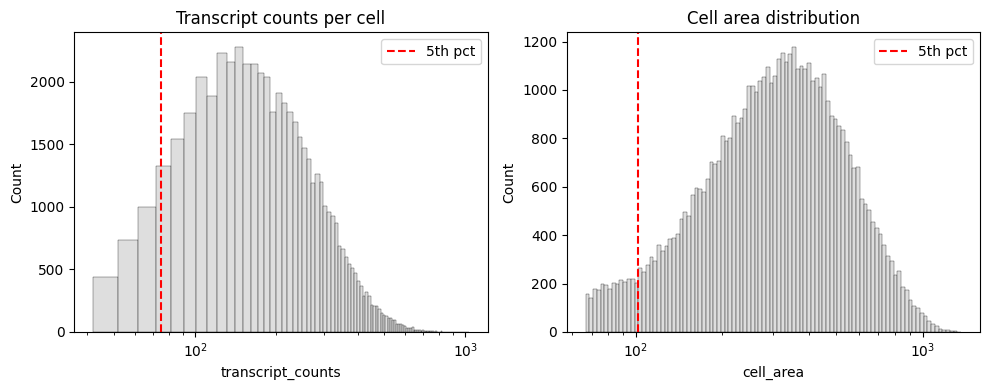

In [8]:
# 4. Filter the cells with <=0 cell area / nucleus area / total number of nonzero genes
# Remove all cells under the5th percentile of transcript count / cell area / nucleus area / total number of nonzero genes
# TODO: the axi are wrong; update them and add nicer labels
filtered_combined_df = filter_cells(
    combined_df, transcript_q=0.05, area_q=0.05, nucleus_q=0.05, genes_q=0.05, gene_cols=gene_cols
)
filtered_combined_df = rename_centroid_columns(filtered_combined_df)
logger.info(
    f"Original: {cells_df.shape[0]} cells → Filtered: {filtered_combined_df.shape[0]} cells"
)
plot_qc_distributions(filtered_combined_df, transcript_q=0.05, area_q=0.05)

In [9]:
# Normalize the data and merge it with the filtered cells
adata_normalized, size_factors = pydeseq2_normalize_global(adata, min_genes=20, apply_log1p=True)
combined_df_normalized = combine_cells_and_expression(
    filtered_combined_df[cells_df.columns],
    adata_normalized,
    f"{PATH_TO_DATA_FOLDER}/combined_normalized.csv",
)
combined_df = combine_cells_and_expression(
    filtered_combined_df[cells_df.columns], adata, f"{PATH_TO_DATA_FOLDER}/combined.csv"
)

🔄 Applying PyDESeq2 median-of-ratios normalization...
Converting to pandas DataFrame for PyDESeq2...
Input data: 62268 cells × 347 genes
Computing size factors using PyDESeq2...
PyDESeq2 returned all NaN size factors, falling back to custom implementation
Computing DESeq2-style size factors...
Computing geometric mean per gene (ignoring zeros)...
Computed geometric means for 347/347 genes
Using 347 genes with defined geometric means
Global median is 0, setting all size factors to 1.0
Size factors computed: median=1.000, range=[1.000, 1.000]
Applying log1p transformation for exploration...
✅ Log1p transformation applied
Size factors computed: median=1.000, range=[1.000, 1.000]
✅ PyDESeq2 normalization complete


In [10]:
# 5. Load the plaque data, build valid polygons
PLAQUES_CSV = Path(f"{PATH_TO_DATA_FOLDER}/plaque_polygons.csv")
plaques_long = load_plaques(PLAQUES_CSV)
plaques_poly = build_polygons(plaques_long)
# 6. Load the brain polygon and ensure it is valid
BRAIN_CSV = Path(f"{PATH_TO_DATA_FOLDER}/brain_polygon.csv")
brain = (
    pd.read_csv(
        BRAIN_CSV, sep=",", header=None, skiprows=2, names=["name", "x", "y"], engine="python"
    )
    .assign(
        x=lambda d: pd.to_numeric(d["x"], errors="coerce"),
        y=lambda d: pd.to_numeric(d["y"], errors="coerce"),
    )
    .dropna(subset=["x", "y"])
    .reset_index(drop=True)
)
brain_xy = brain[["x", "y"]].to_numpy()
brain_geom = close_polygon_if_needed(brain_xy)

logger.info(
    f"plaques_long: {len(plaques_long):,} vertices | plaques_poly: {len(plaques_poly):,} polygons | brain polygon valid: {brain_geom.is_valid}"
)
display(plaques_long.head())
display(plaques_poly.head())

plaques_long: 161,308 vertices | plaques_poly: 1,938 polygons | brain polygon valid: True


,plaque_name,x,y,plaque_id
0,Selection 1,3420.774,4702.540,1
1,Selection 1,3422.074,4702.535,1
2,Selection 1,3422.073,4702.210,1
3,Selection 1,3422.398,4702.209,1
4,Selection 1,3422.396,4701.559,1


,plaque_id,geometry
0,1,"POLYGON ((3420.774 4702.54, 3422.074 4702.535,..."
1,2,"POLYGON ((3086.336 4693.312, 3087.311 4693.308..."
2,3,"POLYGON ((3495.805 4691.228, 3496.78 4691.225,..."
3,4,"POLYGON ((3515.948 4689.532, 3516.598 4689.53,..."
4,5,"POLYGON ((3017.087 4685.43, 3018.387 4685.425,..."


In [11]:
# TODO: migrate to configs
ENFORCE_CONVEX = True
FILL_HOLES = True
REMOVE_NESTED = True
MERGE_OVERLAPS = True

plaques_poly = filter_plaques(
    plaques_poly,
    brain_geom,
    FILL_HOLES=FILL_HOLES,
    ENFORCE_CONVEX=ENFORCE_CONVEX,
    REMOVE_NESTED=REMOVE_NESTED,
    MERGE_OVERLAPS=MERGE_OVERLAPS,
)
display(plaques_poly.head())

{'n_final': 1828, 'polygons': 1828, 'multipolygons': 0, 'holes_present': 1, 'convex': 1803}


,geometry,plaque_id,isPolygon,isMultiPolygon,is_valid,has_holes,is_convex,area,centroid_x,centroid_y,in_brain
0,"POLYGON ((818.959 336.75, 817.984 336.754, 817...",1,True,False,True,False,True,8.765845,819.034449,338.558306,True
1,"POLYGON ((817.401 355.93, 817.075 355.606, 816...",2,True,False,True,False,True,28.410058,817.547747,359.493661,True
2,"POLYGON ((700.007 427.187, 700.004 426.212, 69...",3,True,False,True,False,True,15.314346,697.396075,426.938671,True
3,"POLYGON ((920.401 443.314, 920.072 442.015, 91...",4,True,False,True,False,True,11.037299,918.608001,443.470562,True
4,"POLYGON ((958.882 481.202, 960.507 481.196, 96...",5,True,False,True,False,True,133.495062,959.573450,473.772536,True


{'n_plaques': 1828, 'p5': 6.654350349998617, 'p10': 7.552193399999736, 'IQR_low': 0.0, 'knee_log10_gap': 15766.374772541276}


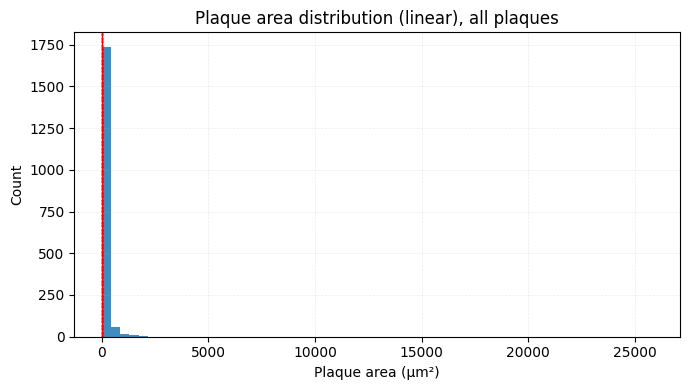

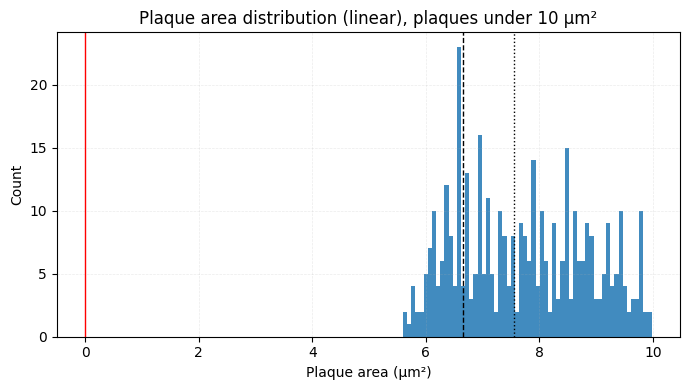

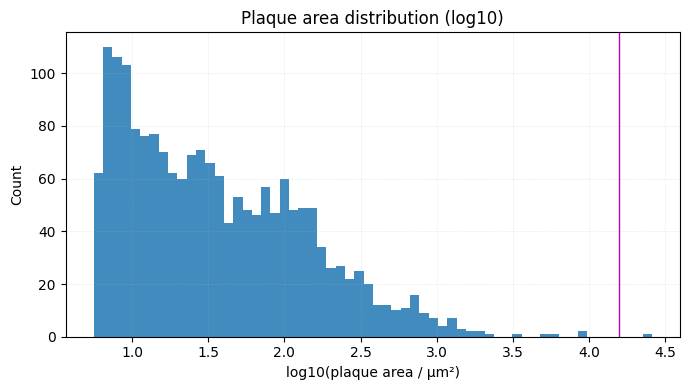

In [12]:
# 7. Plot plaque area distribution to validate suggested cutoffs
areas = plaques_poly["area"].to_numpy()

p5, p10 = np.percentile(areas, [5, 10]) if len(areas) > 0 else (0.0, 0.0)
q1, q3 = np.percentile(areas, [25, 75]) if len(areas) > 0 else (0.0, 0.0)
iqr = q3 - q1
iqr_low = max(0.0, q1 - 1.5 * iqr)

la = np.log10(areas[areas > 0]) if (areas > 0).any() else np.array([])
knee = 0.0
if la.size > 1:
    sl = np.sort(la)
    gap_idx = int(np.argmax(np.diff(sl)))
    knee = 10 ** ((sl[gap_idx] + sl[min(gap_idx + 1, len(sl) - 1)]) / 2)

logger.info(
    {
        "n_plaques": int(len(areas)),
        "p5": float(p5),
        "p10": float(p10),
        "IQR_low": float(iqr_low),
        "knee_log10_gap": float(knee),
    }
)
# Linear area
_ = hist1d(
    areas,
    bins=60,
    thresholds=[
        (p5, "k", "--"),
        (p10, "k", ":"),
        (iqr_low, "r", "-"),
    ],
    xlabel="Plaque area (µm²)",
    ylabel="Count",
    title="Plaque area distribution (linear), all plaques",
    xlim=None,
    ylim=None,
)
areas_filtered = areas[areas < 10]
# Linear area
_ = hist1d(
    areas_filtered,
    bins=60,
    thresholds=[
        (p5, "k", "--"),
        (p10, "k", ":"),
        (iqr_low, "r", "-"),
    ],
    xlabel="Plaque area (µm²)",
    ylabel="Count",
    title="Plaque area distribution (linear), plaques under 10 µm²",
    xlim=None,
    ylim=None,
)

# Log10 area
la = np.log10(areas[areas > 0])
knee_log10 = np.log10(knee) if knee > 0 else None
thr = [(knee_log10, "m", "-")] if knee_log10 is not None else None

_ = hist1d(
    la,
    bins=60,
    thresholds=thr,
    xlabel="log10(plaque area / µm²)",
    ylabel="Count",
    title="Plaque area distribution (log10)",
    xlim=None,
    ylim=None,
)

In [13]:
# 8. Filter out small plaques
AREA_CUTOFF = p5
plaques_poly["removed_small"] = plaques_poly["area"] < AREA_CUTOFF
plaques_poly = plaques_poly[~plaques_poly["removed_small"]].copy()
logger.info(f"kept after area cutoff: {len(plaques_poly):,} out of {len(plaques_poly):,}")

kept after area cutoff: 1,736 out of 1,736


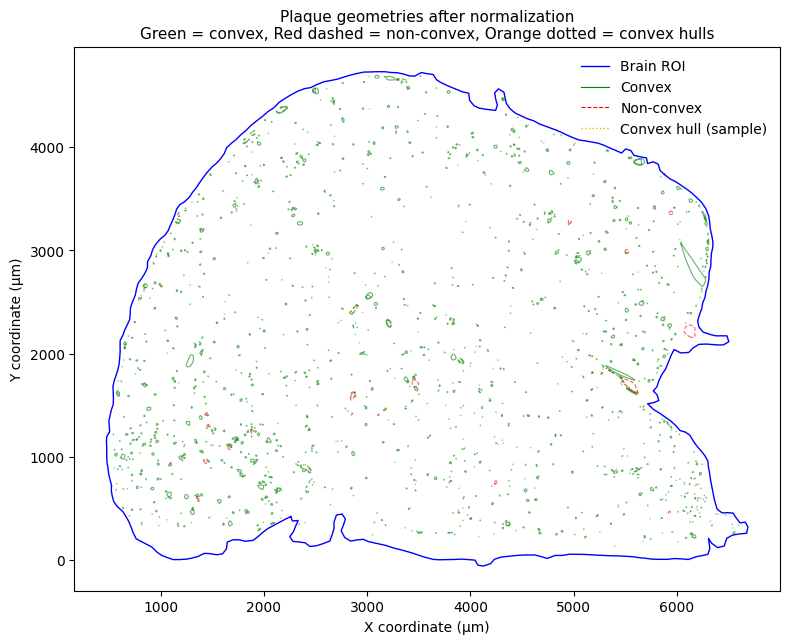

In [14]:
ax = plot_plaques(
    plaques_poly,
    brain_geom=brain_geom if "brain_geom" in globals() else None,
    sample_hulls=20,
    seed=42,
    figsize=(8, 8),
)

In [15]:
logger.info(
    {
        "total": len(plaques_poly),
        "convex": plaques_poly["is_convex"].sum(),
        "non_convex": (~plaques_poly["is_convex"]).sum(),
        "holes_present": plaques_poly["has_holes"].sum(),
        "mean_area": plaques_poly["area"].mean(),
        "in_brain": plaques_poly["in_brain"].mean(),
    }
)

{'total': 1736, 'convex': 1711, 'non_convex': 25, 'holes_present': 1, 'mean_area': 133.9314068292565, 'in_brain': 1.0}


Computing distances: 100%|██████████████████████████████████| 53895/53895 [00:26<00:00, 2016.91it/s]


{'cells': 53895, 'plaques_used': 1736}
{'min': 0.0, 'median': 60.89939421384185, 'mean': 68.0113757185358, 'max': 457.3868408108426, 'n': 53895, 'n_nan': 0}


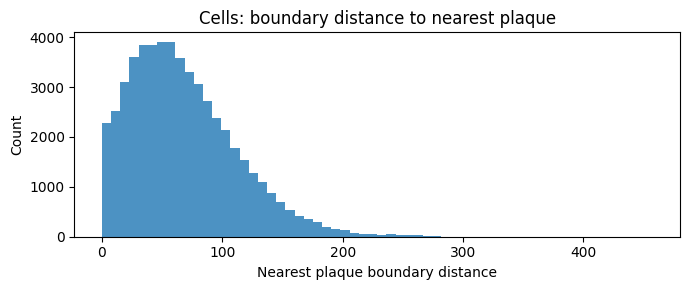

{'bin_counts': {'intermediate': 31032, 'distal': 11606, 'proximal': 11257}}


In [16]:
cells_with_distances = compute_cell_to_plaque_distances(filtered_combined_df, plaques_poly)
df, ax = analyze_plaque_distance(
    cells_with_distances,
    column="nearest_plaque_dist",
    prox_thresh=30.0,
    distal_thresh=100.0,
    logger=logger,
    inplace=True,
)

In [17]:
combined_df_normalized = combined_df_normalized.merge(
    cells_with_distances[
        [
            "cell_id",
            "nearest_plaque_dist",
            "nearest_plaque_center_dist",
            "inside_any_plaque",
            "nearest_plaque_id",
            "nearest_plaque_area",
        ]
    ],
    on="cell_id",
    how="left",
)
combined_df_normalized = combined_df_normalized.dropna(subset=["nearest_plaque_dist"])
combined_df_normalized = combined_df_normalized.rename(
    columns={"nearest_plaque_dist": "distance_to_plaque"}
)

# Preliminary Analysis on Preprocessed Data

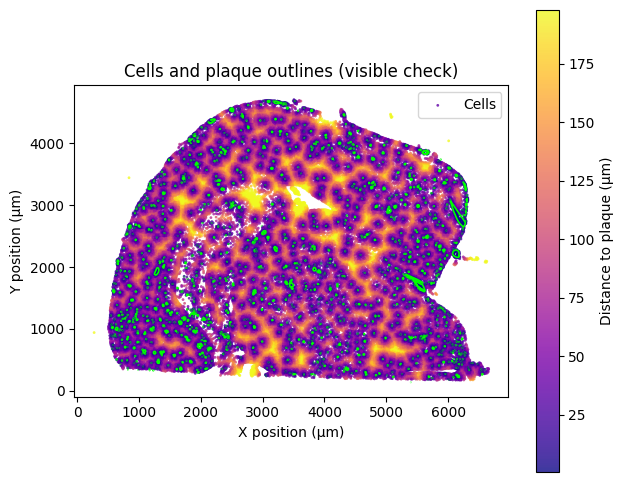

In [122]:
# Compute and visualize per-cell distances
cells_with_distances = cells_with_distances.rename(
    columns={"nearest_plaque_dist": "distance_to_plaque"}
)
import geopandas as gpd

plaques_poly_gdf = gpd.GeoDataFrame({"geometry": plaques_poly["geometry"]})
plot_cell_to_plaque_map_visible(cells_with_distances, plaques_poly_gdf)

Assigning 6 quantile bins by distance_to_plaque
Computing mean expression per bin


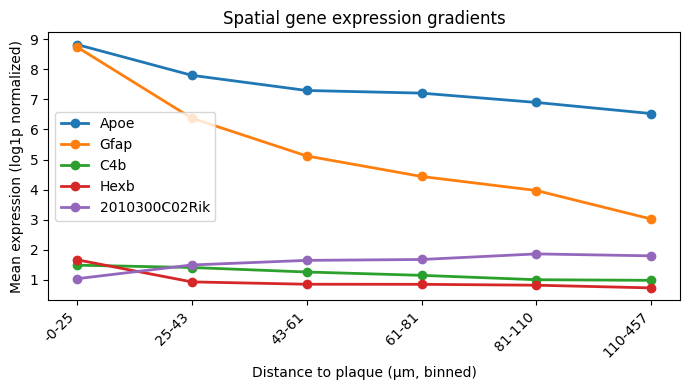

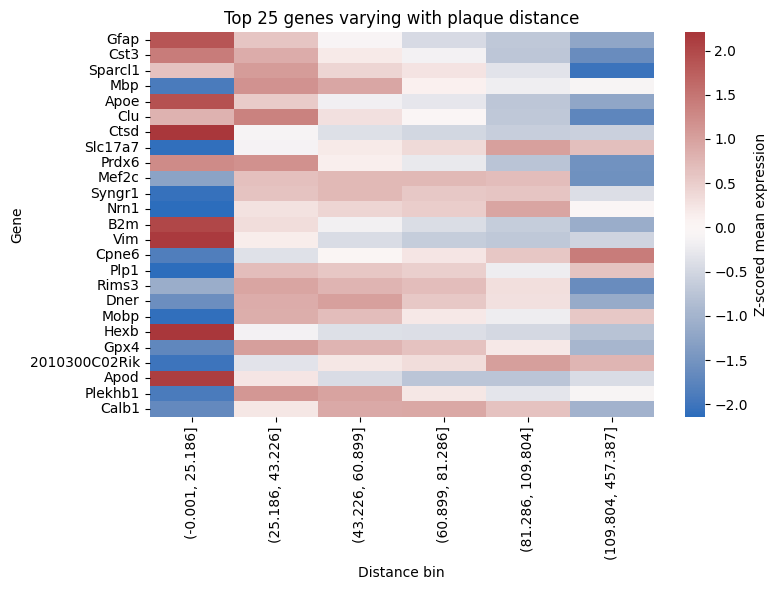

In [123]:
combined_binned = assign_distance_bins(cells_with_distances, n_bins=6)
mean_expr = mean_expression_by_bin(combined_binned, gene_cols)
# Plot trends for known PIG genes
# TODO: Add Error bars
# TODO: Explore the 12 other PIGs
# TODO: 2010300C02Rik seems suspicious - is it a gene?
# TODO: Make bin boundaries decimal
plot_gene_trends(mean_expr, ["Apoe", "Gfap", "C4b", "Hexb", "2010300C02Rik"])
# Visualize top genes with spatial gradients
plot_mean_heatmap(mean_expr, top_n=25)

Computed spatial trends for 347 genes (FDR-corrected).


,gene,spearman_r,spearman_p,slope,fdr_pval
251,Ppp1r1b,0.085456,6.723845e-88,0.000950,6.305876e-87
0,2010300C02Rik,0.085246,1.783830e-87,0.001313,1.587151e-86
304,Spag16,0.084551,4.431051e-86,0.000581,3.843937e-85
75,Cpne6,0.081767,1.310929e-80,0.001480,1.109494e-79
187,Mdga1,0.080811,8.991452e-79,0.000496,7.255892e-78
224,Orai2,0.075141,2.490189e-68,0.000649,1.600177e-67
286,Sipa1l3,0.074637,1.937571e-67,0.000884,1.222431e-66
191,Meis2,0.072477,1.095532e-63,0.000968,6.443215e-63
280,Sema3e,0.072089,5.026624e-63,0.000678,2.907064e-62
22,Bcl11b,0.069869,2.641181e-59,0.000569,1.454746e-58


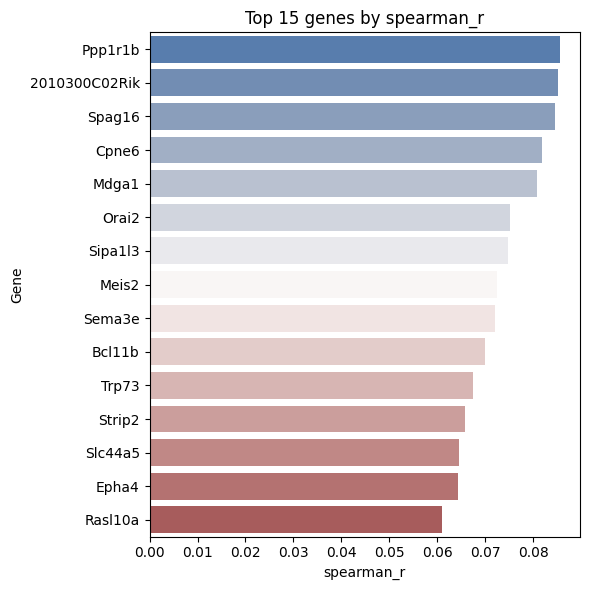

In [124]:
stats_df = compute_gene_spatial_stats(combined_df_normalized, gene_cols)
# filter for significant positive correlations
sig_pos = stats_df.query("fdr_pval < 0.05 and spearman_r > 0").head(15)
display(sig_pos)
# visualize only significant ones
plot_top_spatial_genes(sig_pos, top_n=15, metric="spearman_r")

,gene,spearman_r,spearman_p,slope,fdr_pval,abs_spearman_r
50,Cd69,-0.009679,0.024642,-0.000006,0.030538,0.009679
344,Zfp366,-0.010247,0.017367,-0.000037,0.021678,0.010247
329,Tnf,-0.010553,0.014284,-0.000007,0.017959,0.010553
214,Ntng1,-0.010865,0.011655,-0.000377,0.014706,0.010865
309,Sst,-0.011104,0.009944,-0.000106,0.012593,0.011104
95,Deptor,-0.011668,0.006754,-0.000112,0.008616,0.011668
327,Tmem163,-0.011830,0.006023,-0.000213,0.007741,0.011830
220,Olfml3,-0.011918,0.005661,-0.000027,0.007330,0.011918
124,Gfra2,-0.011993,0.005366,-0.000273,0.007000,0.011993
258,Pthlh,-0.013402,0.001863,-0.000032,0.002486,0.013402


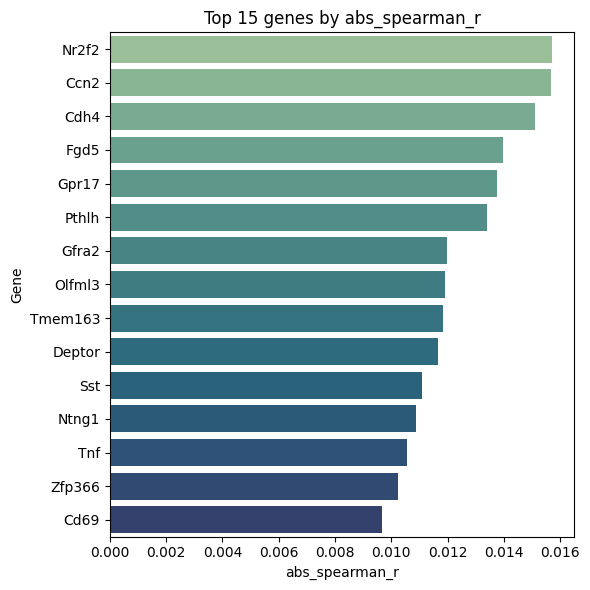

In [125]:
# filter for significant negative correlations
sig_neg = stats_df.query("fdr_pval < 0.05 and spearman_r < 0").head(15)
sig_neg["abs_spearman_r"] = sig_neg["spearman_r"].abs()
display(sig_neg)
plot_top_spatial_genes(sig_neg, top_n=15, metric="abs_spearman_r")

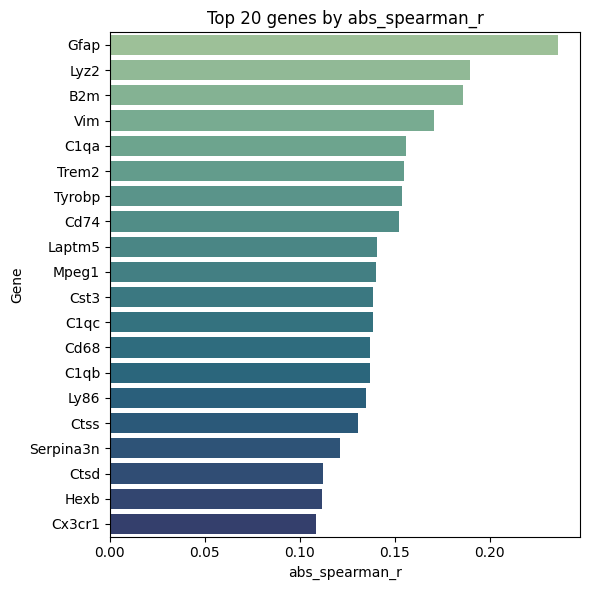

In [126]:
plot_top_spatial_genes(
    stats_df.query("gene != 'total_counts'").assign(abs_spearman_r=stats_df["spearman_r"].abs()),
    metric="abs_spearman_r",
)

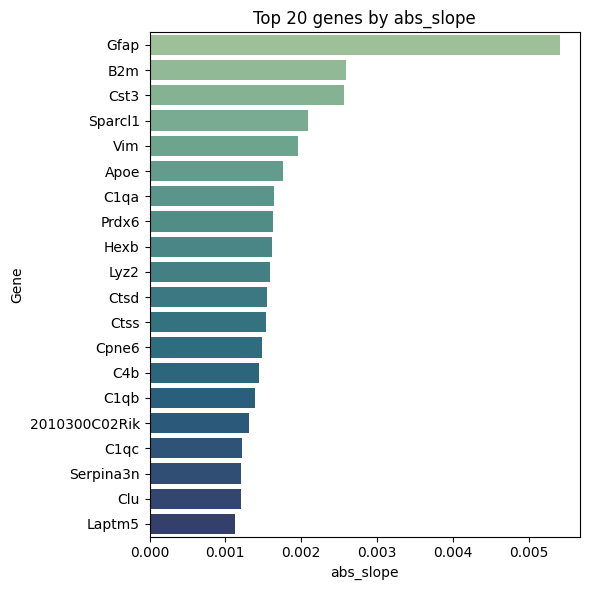

In [127]:
plot_top_spatial_genes(
    stats_df.query("gene != 'total_counts'").assign(abs_slope=stats_df["slope"].abs()),
    metric="abs_slope",
)

# Exploration on gene expression data

In [128]:
# TODO: is it a good idea to normalize before the analysis above?
# 1. Compute per-gene summary statistics on filtered cells

g = filtered_combined_df[gene_cols]
summary = summarize_genes(filtered_combined_df[gene_cols])

logger.info(f"Genes summarized: {len(summary):,}")
display(summary.head(10))

Genes summarized: 347


,mean,std,median,mad,skew,kurtosis,nonzero_frac
gene,,,,,,,
2010300C02Rik,1.585305,2.872429,0.0,0.0,3.058556,13.541861,0.444512
Abca7,0.218239,0.548748,0.0,0.0,3.103318,11.923915,0.168012
Acsbg1,0.773337,1.290938,0.0,0.0,2.683205,10.821354,0.407626
Acta2,0.145524,0.805557,0.0,0.0,12.379254,220.505327,0.080620
Acvrl1,0.100492,0.431734,0.0,0.0,5.907066,45.775163,0.068726
Adamts2,0.131144,0.483844,0.0,0.0,5.436704,44.362929,0.092625
Adamtsl1,0.090936,0.351987,0.0,0.0,5.089143,38.896464,0.074961
Adgrl4,0.172799,0.658692,0.0,0.0,5.422771,38.116629,0.095519
Aldh1a2,0.092495,0.642698,0.0,0.0,11.472683,188.234378,0.037907


In [129]:
# 2. Verify that PIGs are present in the expression data and perform z-normalization for exploration"

pigs_z, info = compute_pigs_zscores(filtered_combined_df, gene_cols)
logger.info(f"PIGs present: {len(info['present'])} | Missing: {info['missing']}")
logger.info(f"Z-scored PIG matrix shape: {pigs_z.shape}")
display(pigs_z.head())

PIGs present: 16 | Missing: []
Z-scored PIG matrix shape: (53895, 16)


,Hexb,Cst3,Cd63,C4b,Ctsd,B2m,H2-K1,Apoe,Gfap,Nrep,Serpina3n,Cd74,Cxcl10,Vim,S100a6,Ifit3
0,-0.494560,0.948647,-0.168951,0.883675,3.507790,0.189909,0.354275,-0.209468,0.352205,4.424604,-0.404441,-0.225795,-0.071031,-0.439027,-0.446673,0.617148
1,0.012388,0.631769,0.402400,-0.601749,-0.046577,1.214806,0.354275,0.230854,0.481630,3.197865,1.780831,-0.225795,-0.071031,0.086851,-0.446673,-0.351437
2,0.012388,0.394111,0.402400,-0.106608,-0.342774,-0.322540,1.312839,1.111499,-0.036067,-0.482354,1.052407,-0.225795,-0.071031,-0.439027,-0.446673,0.617148
3,1.533233,1.344744,2.116452,1.378816,5.581171,3.777050,-0.604289,1.111499,0.611054,6.264713,0.323983,0.762930,-0.071031,0.086851,-0.446673,0.617148
4,0.012388,1.027866,-0.740302,-0.601749,0.545817,-0.834989,0.354275,0.084080,2.681839,3.197865,-0.404441,-0.225795,-0.071031,1.138607,1.847238,-0.351437


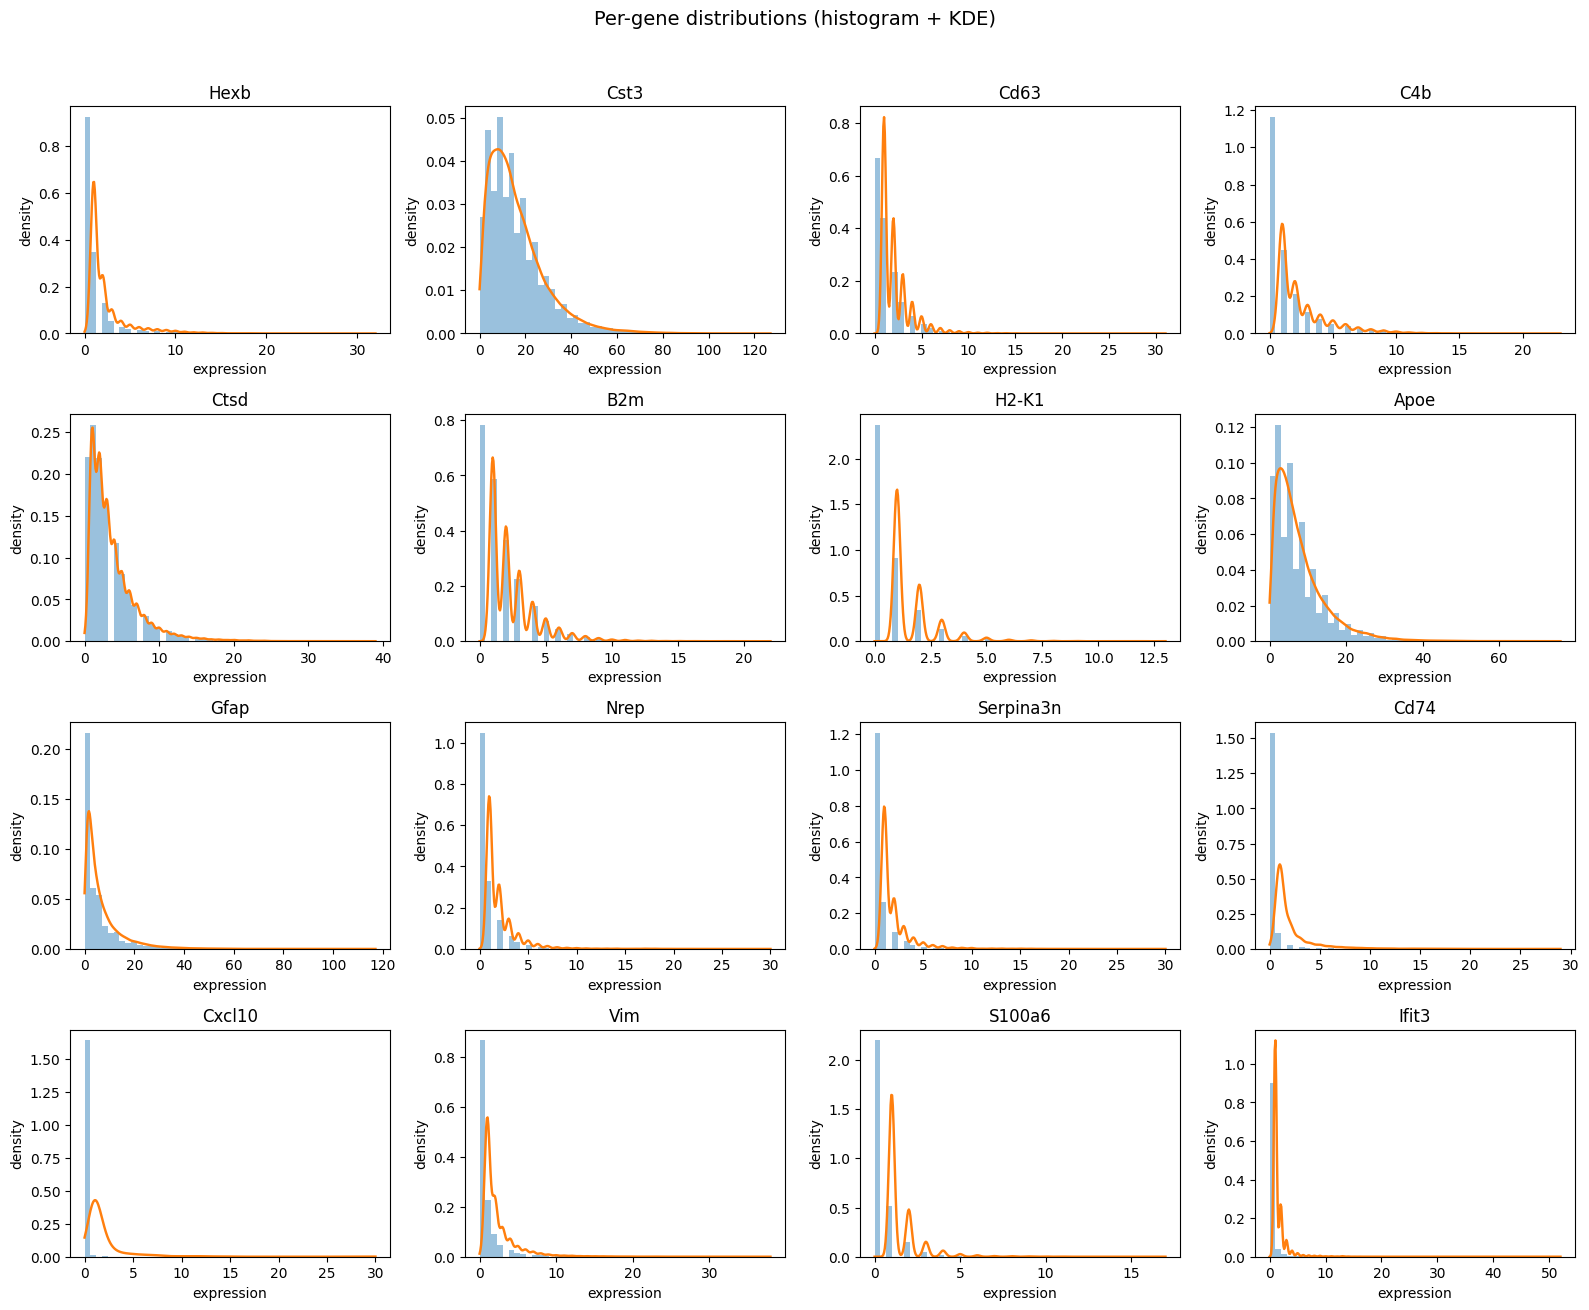

In [130]:
# 3. Plot the histogram + KDE for PIGs
_ = plot_gene_distributions(filtered_combined_df, genes=info["present"])

In [131]:
# 4. For each gene, compute its unusualness based on zero-inflation, dispersion, and shape
S, Z = compute_weird_gene_scores(
    filtered_combined_df[gene_cols], clip_z=3.0, ddof_std=0, PIGs=info["present"]
)
logger.info(f"Genes evaluated: {len(S):,}")
logger.info("\nTop 20 by WEIRD SCORE")
display(S.head(20))
logger.info("\nTop 10 by ZERO FRAC")
display(
    S.sort_values("zero_frac", ascending=False).head(10)[
        ["isPIG", "zero_frac", "mean", "cv", "skew", "kurtosis"]
    ]
)
logger.info("\nTop 10 by |SKEW|")
display(
    S.reindex(S["skew"].abs().sort_values(ascending=False).head(10).index)[
        ["isPIG", "skew", "kurtosis", "zero_frac", "cv"]
    ]
)
logger.info("\nTop 10 by KURTOSIS")
display(
    S.sort_values("kurtosis", ascending=False).head(10)[
        ["isPIG", "kurtosis", "skew", "zero_frac", "cv"]
    ]
)

Genes evaluated: 347

Top 20 by WEIRD SCORE


,zero_frac,nonzero_frac,mean,std,cv,skew,kurtosis,q10,q90,tail_ratio,isPIG,weird_score
Tnf,0.997940,0.002060,0.002227,0.059955,26.927410,72.725511,9587.901700,0.0,0.0,1.0,False,9.428883
Chat,0.994860,0.005140,0.006494,0.123026,18.944303,61.862467,7137.261019,0.0,0.0,1.0,False,9.413116
Cxcl10,0.985861,0.014139,0.027776,0.391045,14.078404,36.332878,2017.429800,0.0,0.0,1.0,True,9.211140
Slc6a3,0.997532,0.002468,0.002987,0.067906,22.731506,32.874628,1507.098365,0.0,0.0,1.0,False,8.500838
Lcn2,0.997922,0.002078,0.002356,0.055948,23.742640,31.765245,1425.312232,0.0,0.0,1.0,False,8.379425
Th,0.985045,0.014955,0.028778,0.366274,12.727484,29.023833,1190.082336,0.0,0.0,1.0,False,7.666800
Cort,0.977864,0.022136,0.033194,0.342104,10.306151,28.137388,1253.944920,0.0,0.0,1.0,False,6.976647
Cd69,0.997792,0.002208,0.002208,0.046937,21.257920,21.211469,447.943040,0.0,0.0,1.0,False,6.150916
Nme8,0.995974,0.004026,0.004230,0.068249,16.132695,17.674773,362.083865,0.0,0.0,1.0,False,5.473340
Dkk2,0.993858,0.006142,0.006661,0.088131,13.230733,15.033796,269.558785,0.0,0.0,1.0,False,4.784686



Top 10 by ZERO FRAC


,isPIG,zero_frac,mean,cv,skew,kurtosis
Tnf,False,0.997940,0.002227,26.927410,72.725511,9587.901700
Lcn2,False,0.997922,0.002356,23.742640,31.765245,1425.312232
Cd69,False,0.997792,0.002208,21.257920,21.211469,447.943040
Slc6a3,False,0.997532,0.002987,22.731506,32.874628,1507.098365
Nme8,False,0.995974,0.004230,16.132695,17.674773,362.083865
Chat,False,0.994860,0.006494,18.944303,61.862467,7137.261019
Dkk2,False,0.993858,0.006661,13.230733,15.033796,269.558785
Ptx3,False,0.991595,0.008906,11.339809,14.000458,292.015996
Tgm1,False,0.990259,0.011615,11.265150,16.348204,400.986170
Crh,False,0.986882,0.021820,11.066071,17.465443,408.090353



Top 10 by |SKEW|


,isPIG,skew,kurtosis,zero_frac,cv
Tnf,False,72.725511,9587.901700,0.997940,26.927410
Chat,False,61.862467,7137.261019,0.994860,18.944303
Cxcl10,True,36.332878,2017.429800,0.985861,14.078404
Slc6a3,False,32.874628,1507.098365,0.997532,22.731506
Lcn2,False,31.765245,1425.312232,0.997922,23.742640
Th,False,29.023833,1190.082336,0.985045,12.727484
Cort,False,28.137388,1253.944920,0.977864,10.306151
Cd69,False,21.211469,447.943040,0.997792,21.257920
Nts,False,19.263740,497.488700,0.967993,9.714287
Ebf3,False,19.153784,646.190699,0.977939,9.008545



Top 10 by KURTOSIS


,isPIG,kurtosis,skew,zero_frac,cv
Tnf,False,9587.901700,72.725511,0.997940,26.927410
Chat,False,7137.261019,61.862467,0.994860,18.944303
Cxcl10,True,2017.429800,36.332878,0.985861,14.078404
Slc6a3,False,1507.098365,32.874628,0.997532,22.731506
Lcn2,False,1425.312232,31.765245,0.997922,23.742640
Cort,False,1253.944920,28.137388,0.977864,10.306151
Th,False,1190.082336,29.023833,0.985045,12.727484
Ebf3,False,646.190699,19.153784,0.977939,9.008545
Nts,False,497.488700,19.263740,0.967993,9.714287
Chodl,False,482.664371,18.214106,0.981909,9.861996


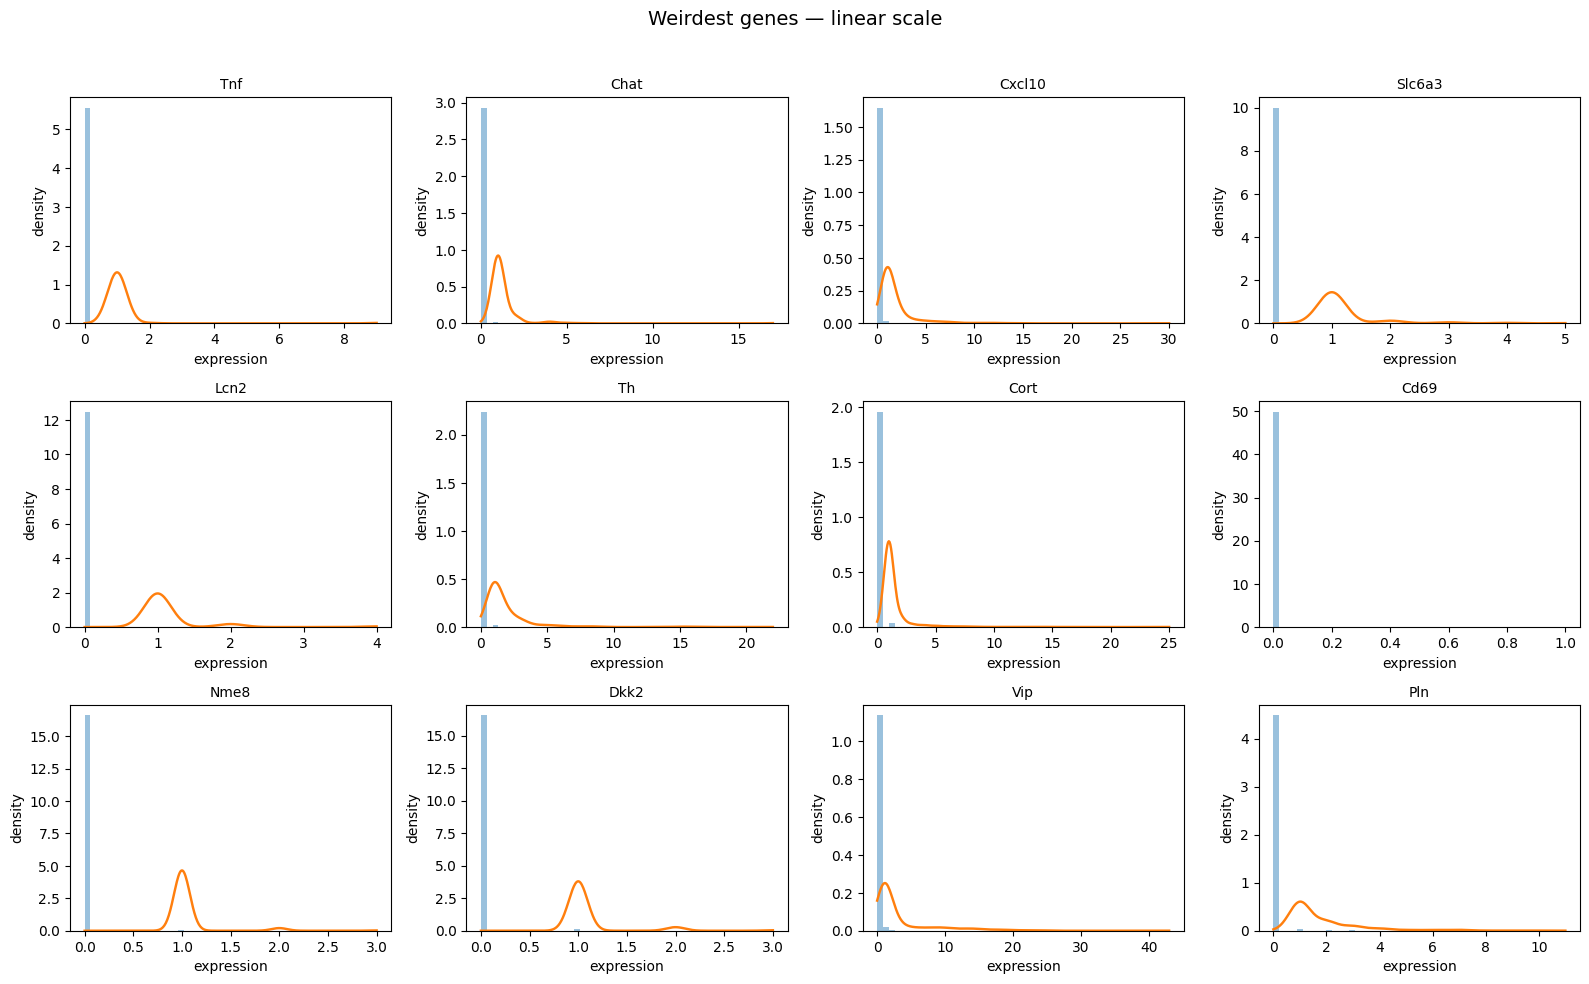

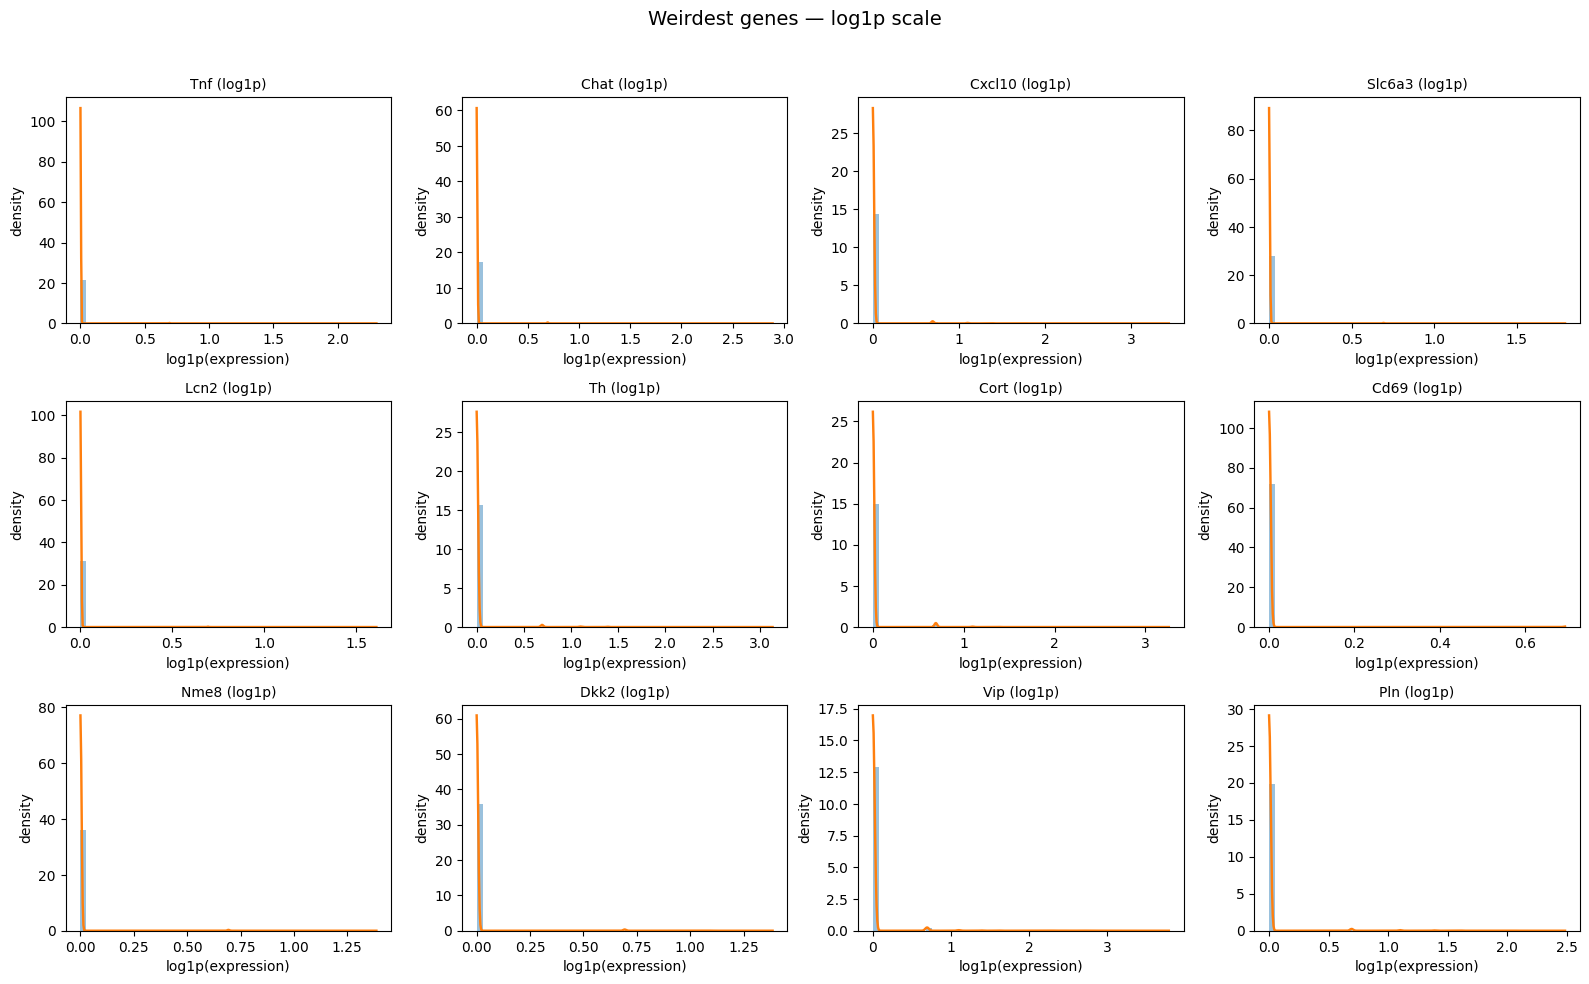

(<Figure size 1600x960 with 12 Axes>, <Figure size 1600x960 with 12 Axes>)

In [132]:
# 5. Plot the historgram and KDE for weirdest genes (linear and log1p)

genes_to_plot = S.head(12).index.tolist()

plot_weird_gene_panels(
    filtered_combined_df,
    genes_to_plot,
    bins=50,
    cols=4,
    show=True,
)

In [133]:
# 6. Save cleaned cells, gene summary, and PIG z-matrix

filtered_combined_df.to_parquet(f"{PATH_TO_DATA_FOLDER}/cells_cleaned.parquet")
summary.to_parquet(f"{PATH_TO_DATA_FOLDER}/gene_summary.parquet")
pigs_z.to_parquet(f"{PATH_TO_DATA_FOLDER}/pigs_z.parquet")
logger.info("Written: cells_cleaned.parquet, gene_summary.parquet, pigs_z.parquet")

Written: cells_cleaned.parquet, gene_summary.parquet, pigs_z.parquet


Research Question 1 — Plaque-Induced Gene (PIG) Expression Gradients

In [134]:
import numpy as np
import pandas as pd

logger.info("=== QC: Combined dataset after merging spatial info ===")
logger.info("Shape:", combined_df_normalized.shape)

# Check key distance columns
key_cols = [
    "distance_to_plaque",
    "nearest_plaque_dist",
    "nearest_plaque_center_dist",
    "nearest_plaque_id",
    "nearest_plaque_area",
    "inside_any_plaque",
]
present = [c for c in key_cols if c in combined_df_normalized.columns]
missing = [c for c in key_cols if c not in combined_df_normalized.columns]
logger.info("\nPresent distance columns:", present)
if missing:
    logger.info("Missing distance columns:", missing)

# Compare consistency of distance columns (they should be almost identical)
if (
    "distance_to_plaque" in combined_df_normalized.columns
    and "nearest_plaque_dist" in combined_df_normalized.columns
):
    diff = (
        combined_df_normalized["distance_to_plaque"] - combined_df_normalized["nearest_plaque_dist"]
    ).abs()
    logger.info("\nDistance difference stats (should be close to 0):")
    logger.info(diff.describe())

# Check for missing values in distance columns
logger.info("\nMissing values per distance column:")
display(combined_df_normalized[key_cols].isna().sum())

# Check distribution of nearest plaque distances
if "nearest_plaque_dist" in combined_df_normalized.columns:
    logger.info("\nNearest plaque distance summary (µm):")
    logger.info(combined_df_normalized["nearest_plaque_dist"].describe())

# Check number of unique plaques referenced
if "nearest_plaque_id" in combined_df_normalized.columns:
    n_unique_plaques = combined_df_normalized["nearest_plaque_id"].nunique()
    logger.info(f"\nUnique plaque IDs linked: {n_unique_plaques}")

# visual sanity check (scatter of coordinates vs distance)
import matplotlib.pyplot as plt

if all(
    c in combined_df_normalized.columns for c in ["x_centroid", "y_centroid", "nearest_plaque_dist"]
):
    sample = combined_df_normalized.sample(2000, random_state=0)
    plt.figure(figsize=(6, 5))
    plt.scatter(
        sample["x_centroid"],
        sample["y_centroid"],
        c=sample["nearest_plaque_dist"],
        cmap="viridis",
        s=4,
        alpha=0.7,
    )
    plt.colorbar(label="Distance to nearest plaque (µm)")
    plt.title("QC Scatter: Cell positions colored by plaque distance")
    plt.xlabel("x_centroid")
    plt.ylabel("y_centroid")
    plt.tight_layout()
    plt.show()

=== QC: Combined dataset after merging spatial info ===

Missing values per distance column:


--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 1100, in emit
    msg = self.format(record)
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 943, in format
    return fmt.format(record)
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 678, in format
    record.message = record.getMessage()
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\site-packages\ipyk

KeyError: "['nearest_plaque_dist'] not in index"

In [135]:
import pandas as pd

PIG_GENES = [
    "Hexb",
    "Cst3",
    "CD63",
    "C4b",
    "Ctsd",
    "B2m",
    "H2-K1",
    "Apoe",
    "Gfap",
    "Nrep",
    "Serpina3n",
    "Cd74",
    "Cxcl10",
    "Vim",
    "S100a6",
    "Ifit3",
]

logger.info("=== Xenium TgCRND8 17.9-month dataset check ===")
logger.info("DataFrame name: combined_df_normalized")
logger.info("Shape:", combined_df_normalized.shape)

# Check core columns
core_cols = ["cell_id", "distance_to_plaque", "x_centroid", "y_centroid"]
logger.info("\nChecking required columns:")
for col in core_cols:
    logger.info(f" - {col}: {'✅' if col in combined_df_normalized.columns else '❌ MISSING'}")

# Check which PIG genes are present
present_genes = [g for g in PIG_GENES if g in combined_df_normalized.columns]
missing_genes = [g for g in PIG_GENES if g not in combined_df_normalized.columns]

logger.info("\nPIG genes present:", present_genes)
logger.info("Missing genes:", missing_genes)

# Quick numeric summary for distance
if "distance_to_plaque" in combined_df_normalized.columns:
    logger.info("\nDistance-to-plaque summary:")
    logger.info(combined_df_normalized["distance_to_plaque"].describe())

# Quick peek at the data
display(combined_df_normalized.head(3))

=== Xenium TgCRND8 17.9-month dataset check ===
DataFrame name: combined_df_normalized

Checking required columns:
 - cell_id: ✅
 - distance_to_plaque: ✅
 - x_centroid: ✅
 - y_centroid: ✅

Distance-to-plaque summary:
count    53895.000000
mean        68.011376
std         44.416354
min          0.000000
25%         34.454704
50%         60.899394
75%         93.897216
max        457.386841
Name: distance_to_plaque, dtype: float64


--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 1100, in emit
    msg = self.format(record)
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 943, in format
    return fmt.format(record)
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 678, in format
    record.message = record.getMessage()
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\logging\__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\rosam\anaconda3\envs\mnlp_exercises\lib\site-packages\ipyk

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Vwc2l,Wfs1,Zfp366,Zfp536,Zfpm2,distance_to_plaque,nearest_plaque_center_dist,inside_any_plaque,nearest_plaque_id,nearest_plaque_area
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,1.386294,0.000000,0.0,0.0,0.693147,35.775568,37.777984,False,18,12.198375
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,1.098612,0.000000,0.0,0.0,0.693147,37.307845,39.655874,False,19,16.476565
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,0.000000,0.693147,0.0,0.0,1.098612,23.175138,25.481295,False,19,16.476565


Step 2 – Bin cells by distance and compute average PIG expression

In [ ]:
import numpy as np
import pandas as pd

# Define the distance bins (in µm)
bins = [0, 20, 50, 100, 200, np.inf]
labels = ["0–20 µm", "20–50 µm", "50–100 µm", "100–200 µm", ">200 µm"]

combined_df_normalized["distance_bin"] = pd.cut(
    combined_df_normalized["nearest_plaque_dist"], bins=bins, labels=labels, include_lowest=True
)

# Define which PIG genes are available
PIG_GENES = [
    "Hexb",
    "Cst3",
    "C4b",
    "Ctsd",
    "B2m",
    "H2-K1",
    "Apoe",
    "Gfap",
    "Nrep",
    "Serpina3n",
    "Cd74",
    "Cxcl10",
    "Vim",
    "S100a6",
    "Ifit3",  # CD63 missing in dataset
]
pig_cols = [g for g in PIG_GENES if g in combined_df_normalized.columns]

# Compute mean and standard error for each distance bin
mean_expr = combined_df_normalized.groupby("distance_bin")[pig_cols].mean().reset_index()
sem_expr = combined_df_normalized.groupby("distance_bin")[pig_cols].sem().reset_index()

# Merge for clarity
summary_df = mean_expr.melt(id_vars="distance_bin", var_name="gene", value_name="mean_expr")
sem_melted = sem_expr.melt(id_vars="distance_bin", var_name="gene", value_name="sem_expr")
summary_df = summary_df.merge(sem_melted, on=["distance_bin", "gene"], how="left")

logger.info("Mean ± SEM of PIG expression by distance bin:")
display(summary_df.head(15))

# Also check how many cells fall into each bin
logger.info("\nCell counts per distance bin:")
display(combined_df_normalized["distance_bin"].value_counts().sort_index())

KeyError: 'nearest_plaque_dist'

Step 3 — Visualize Expression vs Distance

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

genes_to_plot = [g for g in PIG_GENES if g in summary_df["gene"].unique()]

n_genes = len(genes_to_plot)
n_cols = 4
n_rows = int(np.ceil(n_genes / n_cols))

sns.set(style="whitegrid")
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 2.5), sharey=True)
axes = axes.flatten()

for i, g in enumerate(genes_to_plot):
    df = summary_df[summary_df["gene"] == g]
    ax = axes[i]
    ax.errorbar(
        df["distance_bin"],
        df["mean_expr"],
        yerr=df["sem_expr"],
        marker="o",
        capsize=3,
        linewidth=1,
    )
    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

# Global labels
fig.suptitle(
    "Expression of Plaque-Induced Genes vs Distance to Plaque (TgCRND8 17.9m)", fontsize=14
)
fig.text(0.5, 0.04, "Distance bin", ha="center", fontsize=12)
fig.text(0.04, 0.5, "Mean log-expression (± SEM)", va="center", rotation="vertical", fontsize=12)
plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

NameError: name 'summary_df' is not defined

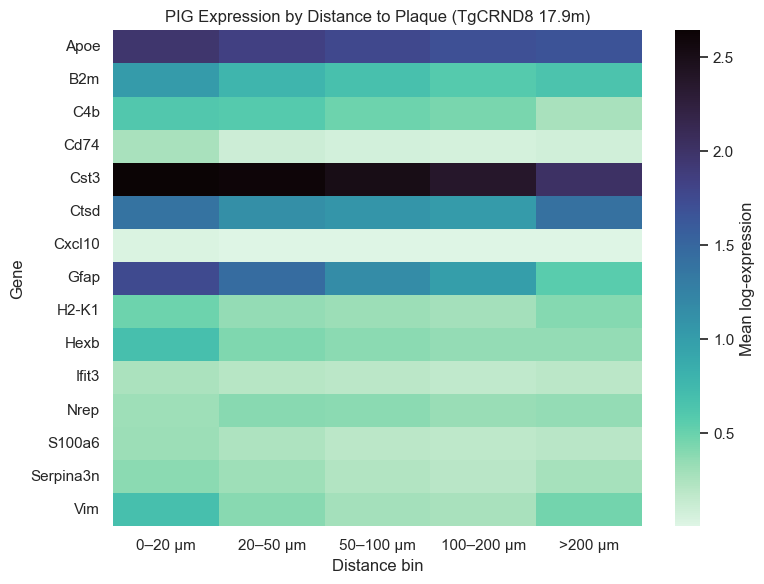

In [ ]:
plt.figure(figsize=(8, 6))
heatmap_df = summary_df.pivot(index="gene", columns="distance_bin", values="mean_expr")
sns.heatmap(heatmap_df, cmap="mako_r", cbar_kws={"label": "Mean log-expression"})
plt.title("PIG Expression by Distance to Plaque (TgCRND8 17.9m)")
plt.xlabel("Distance bin")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

proximal plaques show elevated microglial (Hexb, Ctsd, Cst3, Apoe) and astrocytic (Gfap, Serpina3n, Vim) expression that fades with distance.

Step 4a — Continuous model: per-gene linear regression

In [ ]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

results = []

# Use all available PIG genes
pig_cols = [g for g in PIG_GENES if g in combined_df_normalized.columns]

for gene in pig_cols:
    df = combined_df_normalized[[gene, "nearest_plaque_dist"]].dropna()
    X = sm.add_constant(df["nearest_plaque_dist"])  # adds intercept
    y = df[gene]
    model = sm.OLS(y, X).fit()
    slope = model.params["nearest_plaque_dist"]
    pval = model.pvalues["nearest_plaque_dist"]
    results.append({"gene": gene, "slope": slope, "pval": pval})

# Convert to DataFrame
reg_df = pd.DataFrame(results)
reg_df["qval"] = multipletests(reg_df["pval"], method="fdr_bh")[1]
reg_df = reg_df.sort_values("slope")

logger.info("Continuous regression results (expression ~ distance):")
display(reg_df)

# Highlight top plaque-proximal genes (negative slope)
proximal_genes = reg_df[reg_df["slope"] < 0].sort_values("qval").head(10)
logger.info("\nTop plaque-proximal genes (negative slope, smallest q-values):")
display(proximal_genes)

Continuous regression results (expression ~ distance):


,gene,slope,pval,qval
7,Gfap,-0.005313,0.000000e+00,0.000000e+00
1,Cst3,-0.002509,5.223421e-234,1.958783e-233
4,B2m,-0.002498,0.000000e+00,0.000000e+00
12,Vim,-0.001909,3.814466e-268,1.907233e-267
6,Apoe,-0.001712,8.565298e-109,1.284795e-108
0,Hexb,-0.001610,4.513449e-178,1.128362e-177
3,Ctsd,-0.001541,2.803488e-108,3.822938e-108
2,C4b,-0.001405,3.996474e-116,7.493388e-116
9,Serpina3n,-0.001157,9.263298e-142,1.984993e-141
10,Cd74,-0.000984,1.537710e-210,4.613131e-210



Top plaque-proximal genes (negative slope, smallest q-values):


,gene,slope,pval,qval
7,Gfap,-0.005313,0.000000e+00,0.000000e+00
4,B2m,-0.002498,0.000000e+00,0.000000e+00
12,Vim,-0.001909,3.814466e-268,1.907233e-267
1,Cst3,-0.002509,5.223421e-234,1.958783e-233
10,Cd74,-0.000984,1.537710e-210,4.613131e-210
0,Hexb,-0.001610,4.513449e-178,1.128362e-177
9,Serpina3n,-0.001157,9.263298e-142,1.984993e-141
2,C4b,-0.001405,3.996474e-116,7.493388e-116
13,S100a6,-0.000868,5.654290e-116,9.423817e-116
6,Apoe,-0.001712,8.565298e-109,1.284795e-108


Each slope shows how much the log-expression changes per micron away from a plaque. Gene expression decreases as you move away from plaques — consistent with microglial/astrocytic activation. Top genes: Gfap, Cst3, Apoe, Hexb, Serpina3n, Vim are canonical plaque-induced genes
Slopes are small but consistent (−0.001 to −0.005) Because the unit is µm; a 100 µm shift corresponds to roughly 0.1–0.5 log change. Nrep, Ifit3, Cxcl10 show weak slopes so these genes are less spatially patterned.

Step 4b — Categorical model (ANOVA-style)

In [ ]:
import re

import statsmodels.formula.api as smf

anova_results = []

for gene in pig_cols:
    df = combined_df_normalized[[gene, "distance_bin"]].dropna()
    safe_gene = re.sub(r"[^0-9a-zA-Z_]", "_", gene)  # replace symbols like "-" with "_"
    df = df.rename(columns={gene: safe_gene})

    model = smf.ols(f"{safe_gene} ~ C(distance_bin)", data=df).fit()
    aov_table = sm.stats.anova_lm(model, typ=2)
    pval = aov_table["PR(>F)"].iloc[0]
    anova_results.append({"gene": gene, "anova_pval": pval})

anova_df = pd.DataFrame(anova_results)
anova_df["qval"] = multipletests(anova_df["anova_pval"], method="fdr_bh")[1]
anova_df = anova_df.sort_values("anova_pval")

logger.info("Categorical ANOVA results (expression ~ distance_bin):")
display(anova_df.head(10))

Categorical ANOVA results (expression ~ distance_bin):


,gene,anova_pval,qval
0,Hexb,0.000000e+00,0.000000e+00
4,B2m,0.000000e+00,0.000000e+00
7,Gfap,0.000000e+00,0.000000e+00
10,Cd74,0.000000e+00,0.000000e+00
12,Vim,0.000000e+00,0.000000e+00
3,Ctsd,1.180158e-272,2.950396e-272
1,Cst3,3.698604e-213,7.925580e-213
9,Serpina3n,2.291455e-189,4.296478e-189
13,S100a6,1.638297e-184,2.730496e-184
5,H2-K1,2.171029e-178,3.256544e-178


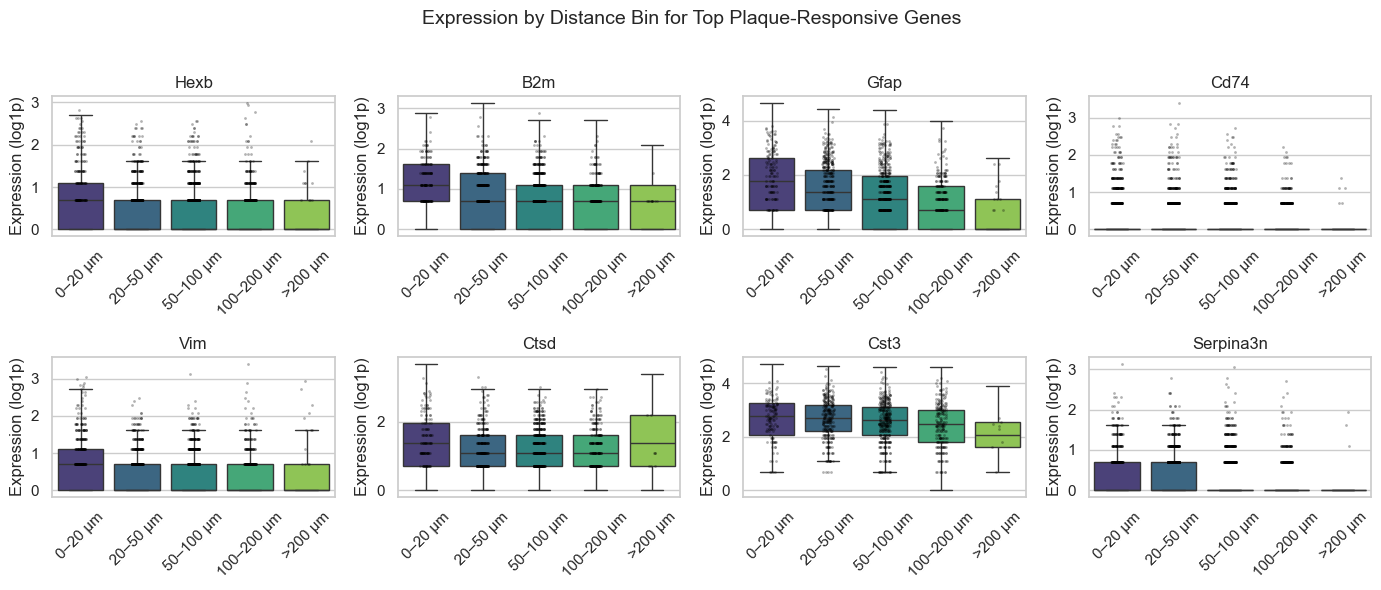

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

top_genes = anova_df.sort_values("qval").head(8)["gene"].tolist()

n_cols = 4
n_rows = int(np.ceil(len(top_genes) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3), sharey=False)
axes = axes.flatten()

for i, g in enumerate(top_genes):
    ax = axes[i]

    # --- Base boxplot
    sns.boxplot(
        data=combined_df_normalized,
        x="distance_bin",
        y=g,
        ax=ax,
        showfliers=False,
        palette="viridis",
    )

    # --- Overlay nonzero points for sparse genes (e.g., Cd74)
    nonzero = combined_df_normalized[combined_df_normalized[g] > 0]
    if len(nonzero) > 0:
        # sample up to 1000 points for speed
        sample = nonzero.sample(min(1000, len(nonzero)), random_state=0)
        sns.stripplot(
            data=sample, x="distance_bin", y=g, ax=ax, color="black", size=2, alpha=0.3, jitter=True
        )

    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylabel("Expression (log1p)")
    ax.tick_params(axis="x", rotation=45)

# --- Figure formatting
fig.suptitle("Expression by Distance Bin for Top Plaque-Responsive Genes", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# --- merge continuous and categorical stats safely
summary_stats = reg_df.rename(columns={"pval": "pval_continuous", "qval": "qval_continuous"}).merge(
    anova_df.rename(columns={"pval": "anova_pval", "qval": "qval_anova"}), on="gene", how="left"
)

summary_stats = summary_stats.sort_values("slope")

# --- show top genes
cols_to_show = [
    c
    for c in ["gene", "slope", "pval_continuous", "qval_continuous", "anova_pval", "qval_anova"]
    if c in summary_stats.columns
]

logger.info("=== Top plaque-proximal genes (negative slope, smallest q-values) ===")
display(summary_stats.head(10)[cols_to_show])

logger.info("\n=== Least plaque-responsive genes (weakest or flat slopes) ===")
display(summary_stats.tail(5)[cols_to_show])

=== Top plaque-proximal genes (negative slope, smallest q-values) ===


,gene,slope,pval_continuous,qval_continuous,anova_pval,qval_anova
0,Gfap,-0.005313,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,Cst3,-0.002509,5.223421e-234,1.958783e-233,3.698604e-213,7.925580e-213
2,B2m,-0.002498,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Vim,-0.001909,3.814466e-268,1.907233e-267,0.000000e+00,0.000000e+00
4,Apoe,-0.001712,8.565298e-109,1.284795e-108,1.770485e-118,2.213106e-118
5,Hexb,-0.001610,4.513449e-178,1.128362e-177,0.000000e+00,0.000000e+00
6,Ctsd,-0.001541,2.803488e-108,3.822938e-108,1.180158e-272,2.950396e-272
7,C4b,-0.001405,3.996474e-116,7.493388e-116,4.072558e-121,5.553488e-121
8,Serpina3n,-0.001157,9.263298e-142,1.984993e-141,2.291455e-189,4.296478e-189
9,Cd74,-0.000984,1.537710e-210,4.613131e-210,0.000000e+00,0.000000e+00



=== Least plaque-responsive genes (weakest or flat slopes) ===


,gene,slope,pval_continuous,qval_continuous,anova_pval,qval_anova
10,H2-K1,-0.000944,1.256338e-97,1.570422e-97,2.171029e-178,3.256544e-178
11,S100a6,-0.000868,5.654290e-116,9.423817e-116,1.638297e-184,2.730496e-184
12,Ifit3,-0.000530,1.935350e-46,2.233096e-46,1.942709e-61,2.081474e-61
13,Nrep,-0.000217,2.608811e-05,2.608811e-05,5.315834e-38,5.315834e-38
14,Cxcl10,-0.000152,2.229331e-41,2.388569e-41,1.604657e-69,1.851527e-69


Research Question 2 — Cell Type Frequency Gradients

Identify gene columns and build a clustering matrix

=== Distance to nearest plaque (µm) summary ===
count    56956.000000
mean        68.557212
std         44.787599
min          0.000000
25%         34.673606
50%         61.516188
75%         94.578283
max        457.648172
Name: nearest_plaque_dist, dtype: float64


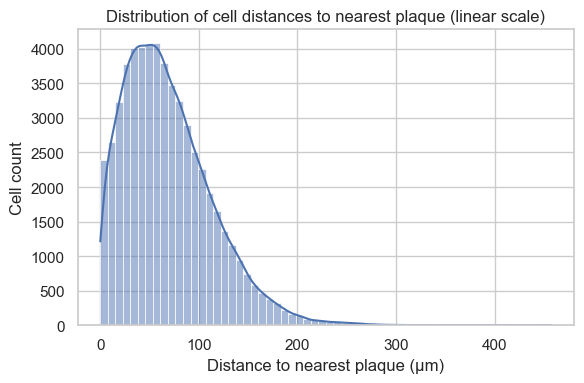

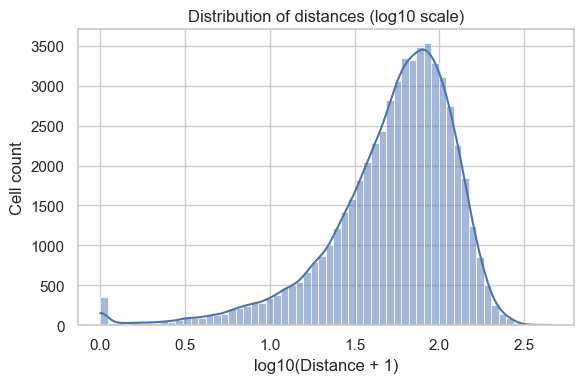

{'5%': 9.031616891188534, '25%': 34.67360612791328, '50% (median)': 61.516187627686264, '75%': 94.578282649893, '95%': 151.07227456103567}

=== Cell counts by proximity class ===
dist_bin_simple
intermediate (30–100 µm)    32665
distal (>100 µm)            12496
proximal (<30 µm)           11795
Name: count, dtype: int64


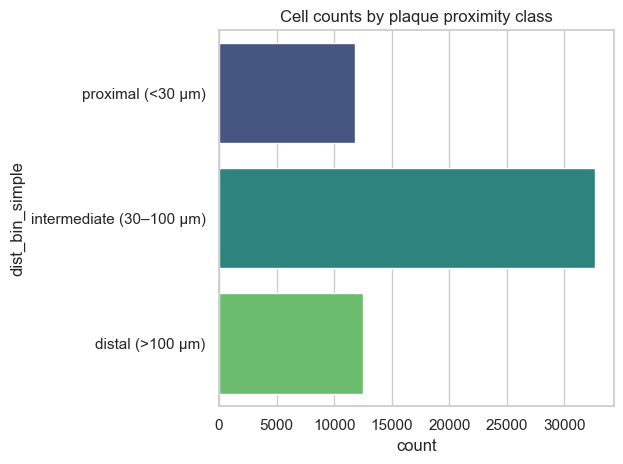

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = combined_df_normalized

# --- 1. Basic summary statistics
logger.info("=== Distance to nearest plaque (µm) summary ===")
logger.info(df["nearest_plaque_dist"].describe())

# --- 2. Histogram (linear scale)
plt.figure(figsize=(6, 4))
sns.histplot(df["nearest_plaque_dist"], bins=60, kde=True)
plt.xlabel("Distance to nearest plaque (µm)")
plt.ylabel("Cell count")
plt.title("Distribution of cell distances to nearest plaque (linear scale)")
plt.tight_layout()
plt.show()

# --- 3. Histogram (log scale)
plt.figure(figsize=(6, 4))
sns.histplot(np.log10(df["nearest_plaque_dist"] + 1), bins=60, kde=True)
plt.xlabel("log10(Distance + 1)")
plt.ylabel("Cell count")
plt.title("Distribution of distances (log10 scale)")
plt.tight_layout()
plt.show()

# --- 4. Quantiles and thresholds
q5, q25, q50, q75, q95 = np.percentile(df["nearest_plaque_dist"].dropna(), [5, 25, 50, 75, 95])
logger.info({"5%": q5, "25%": q25, "50% (median)": q50, "75%": q75, "95%": q95})

# --- 5. How many cells are proximal/intermediate/distal
PROX_THRESH = 30
DISTAL_THRESH = 100

bins = [0, PROX_THRESH, DISTAL_THRESH, np.inf]
labels = ["proximal (<30 µm)", "intermediate (30–100 µm)", "distal (>100 µm)"]
df["dist_bin_simple"] = pd.cut(
    df["nearest_plaque_dist"], bins=bins, labels=labels, include_lowest=True
)

logger.info("\n=== Cell counts by proximity class ===")
logger.info(df["dist_bin_simple"].value_counts())
sns.countplot(y="dist_bin_simple", data=df, order=labels, palette="viridis")
plt.title("Cell counts by plaque proximity class")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc

df = combined_df_normalized.copy()

# --- 1. Identify gene expression columns (numeric, excluding metadata)
meta_cols = {
    "cell_id",
    "x_centroid",
    "y_centroid",
    "transcript_counts",
    "control_probe_counts",
    "control_codeword_counts",
    "unassigned_codeword_counts",
    "total_counts",
    "cell_area",
    "nucleus_area",
    "distance_to_plaque",
    "nearest_plaque_dist",
    "nearest_plaque_center_dist",
    "inside_any_plaque",
    "nearest_plaque_id",
    "nearest_plaque_area",
    "distance_bin",
    "dist_bin_simple",
}
gene_cols = [c for c in df.columns if c not in meta_cols and np.issubdtype(df[c].dtype, np.number)]

logger.info(f"Detected {len(gene_cols)} gene columns")

# --- 2. Build AnnData object for Scanpy
adata = sc.AnnData(df[gene_cols].values)
adata.obs = df[["cell_id", "nearest_plaque_dist", "dist_bin_simple"]].copy()
adata.obs_names = df["cell_id"].astype(str)
adata.var_names = gene_cols

logger.info(adata)

Detected 347 gene columns
AnnData object with n_obs × n_vars = 56956 × 347
    obs: 'cell_id', 'nearest_plaque_dist', 'dist_bin_simple'


=== Step 4: PCA → Neighbors → Leiden Clustering ===
leiden
0     10573
1      6985
2      5836
3      4117
4      4056
5      3717
6      3121
7      2409
8      2184
9      2098
10     2033
11     1883
12     1671
13     1621
14     1173
15      955
16      789
17      615
18      480
19      464
20      176
Name: count, dtype: int64


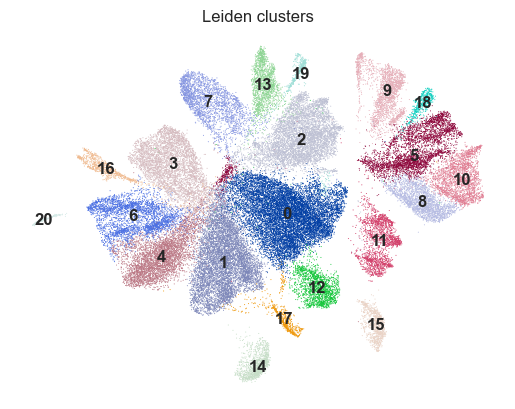

Added 'cluster_leiden' column to combined_df_2 ✅


In [ ]:
import scanpy as sc

logger.info("=== Step 4: PCA → Neighbors → Leiden Clustering ===")

# --- 1. Basic preprocessing
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=30, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

# --- 2. Leiden clustering
sc.tl.leiden(adata, resolution=0.6, key_added="leiden")
logger.info(adata.obs["leiden"].value_counts())

# --- 3. UMAP for visualization
sc.tl.umap(adata)
sc.pl.umap(adata, color=["leiden"], legend_loc="on data", frameon=False, title="Leiden clusters")

# --- 4. Add cluster labels back to the main dataframe
combined_df_normalized["cluster_leiden"] = adata.obs["leiden"].values
logger.info("Added 'cluster_leiden' column to combined_df_normalized ✅")

=== Spatial distribution of Leiden clusters ===


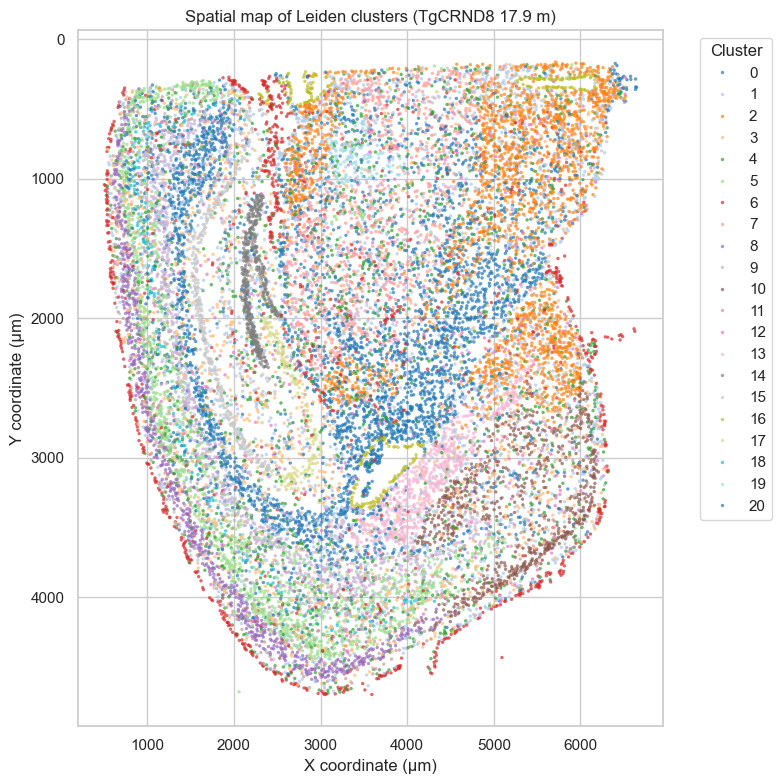

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

logger.info("=== Spatial distribution of Leiden clusters ===")

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=combined_df_normalized.sample(20000, random_state=0),  # subsample for speed
    x="x_centroid",
    y="y_centroid",
    hue="cluster_leiden",
    palette="tab20",
    s=6,
    linewidth=0,
    alpha=0.7,
)
plt.gca().invert_yaxis()  # to match microscopy orientation
plt.title("Spatial map of Leiden clusters (TgCRND8 17.9 m)")
plt.xlabel("X coordinate (µm)")
plt.ylabel("Y coordinate (µm)")
plt.legend(bbox_to_anchor=(1.05, 1), title="Cluster", ncol=1)
plt.tight_layout()
plt.show()

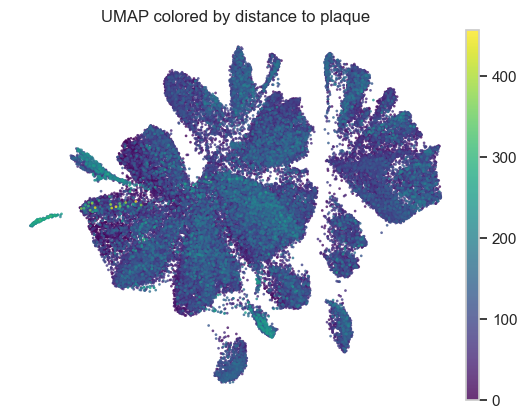

In [ ]:
sc.pl.umap(
    adata,
    color=["nearest_plaque_dist"],
    color_map="viridis",
    size=15,
    alpha=0.8,
    frameon=False,
    title="UMAP colored by distance to plaque",
)

=== Step 5 (Continuous): Cluster frequency vs. continuous distance ===


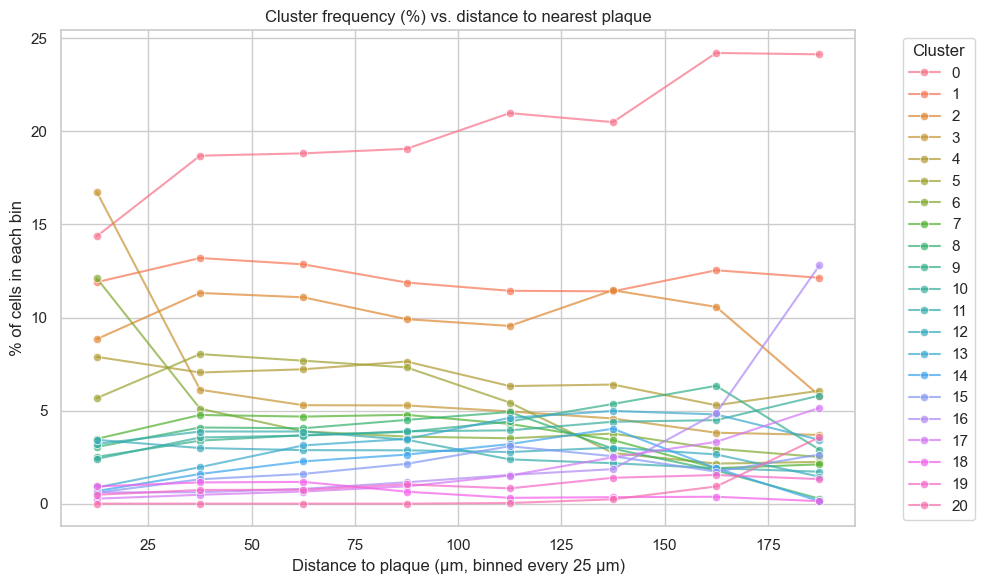

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

logger.info("=== Step 5 (Continuous): Cluster frequency vs. continuous distance ===")

# --- 1. Bin distances smoothly (e.g., 0–25 µm, 25–50 µm, ... up to ~200 µm)
max_dist = np.percentile(combined_df_normalized["nearest_plaque_dist"], 99)
bins = np.arange(0, max_dist + 25, 25)
combined_df_normalized["distance_bin_cont"] = pd.cut(
    combined_df_normalized["nearest_plaque_dist"], bins=bins
)

# --- 2. Compute cluster frequencies per distance bin
freq_df = (
    combined_df_normalized.groupby(["distance_bin_cont", "cluster_leiden"])
    .size()
    .reset_index(name="n_cells")
)

# Total cells per distance bin
totals = (
    combined_df_normalized["distance_bin_cont"]
    .value_counts()
    .rename_axis("distance_bin_cont")
    .reset_index(name="total_cells")
)
freq_df = freq_df.merge(totals, on="distance_bin_cont", how="left")
freq_df["pct"] = 100 * freq_df["n_cells"] / freq_df["total_cells"]

# --- 3. Convert bin labels to midpoints for plotting
freq_df["bin_mid"] = freq_df["distance_bin_cont"].apply(lambda x: x.mid if pd.notna(x) else np.nan)

# --- 4. Plot continuous trend per cluster
plt.figure(figsize=(10, 6))
sns.lineplot(data=freq_df, x="bin_mid", y="pct", hue="cluster_leiden", marker="o", alpha=0.7)
plt.title("Cluster frequency (%) vs. distance to nearest plaque")
plt.xlabel("Distance to plaque (µm, binned every 25 µm)")
plt.ylabel("% of cells in each bin")
plt.legend(bbox_to_anchor=(1.05, 1), title="Cluster", ncol=1)
plt.tight_layout()
plt.show()

In [ ]:
freq_df.head()

,distance_bin_cont,cluster_leiden,n_cells,total_cells,pct,bin_mid
0,"(0.0, 25.0]",0,1292,8990,14.371524,12.5
1,"(0.0, 25.0]",1,1070,8990,11.902113,12.5
2,"(0.0, 25.0]",2,795,8990,8.843159,12.5
3,"(0.0, 25.0]",3,1505,8990,16.740823,12.5
4,"(0.0, 25.0]",4,709,8990,7.886541,12.5


In [ ]:
import pandas as pd
from statsmodels.formula.api import logit

# Binary label: near vs far
combined_df_normalized["is_proximal"] = (
    combined_df_normalized["nearest_plaque_dist"] <= 30
).astype(int)

results = []
for cl in combined_df_normalized["cluster_leiden"].unique():
    df_cl = combined_df_normalized.copy()
    df_cl["in_cluster"] = (df_cl["cluster_leiden"] == cl).astype(int)
    model = logit("in_cluster ~ nearest_plaque_dist", data=df_cl).fit(disp=0)
    slope = model.params["nearest_plaque_dist"]
    pval = model.pvalues["nearest_plaque_dist"]
    results.append({"cluster": cl, "slope": slope, "pval": pval})

logit_df = pd.DataFrame(results)
logit_df["adj_pval"] = np.minimum(logit_df["pval"] * len(logit_df), 1.0)
display(logit_df.sort_values("pval").head(10))

,cluster,slope,pval,adj_pval
16,16,0.017737,6.317548e-196,1.326685e-194
9,3,-0.013184,2.302230e-179,4.834683e-178
11,17,0.017434,3.775873e-156,7.929334e-155
20,20,0.041735,7.536239e-156,1.582610e-154
7,6,-0.010674,8.635768e-100,1.813511e-98
15,13,0.007320,5.336404e-52,1.120645e-50
12,15,0.006346,8.504663e-24,1.785979e-22
1,5,-0.004028,7.016621e-23,1.473490e-21
6,0,0.002245,8.738884e-22,1.835166e-20
18,14,0.005523,2.709737e-21,5.690448e-20


Slope < 0	Cluster becomes more common near plaques (enriched proximally).
Slope > 0	Cluster becomes less common near plaques (enriched distally).

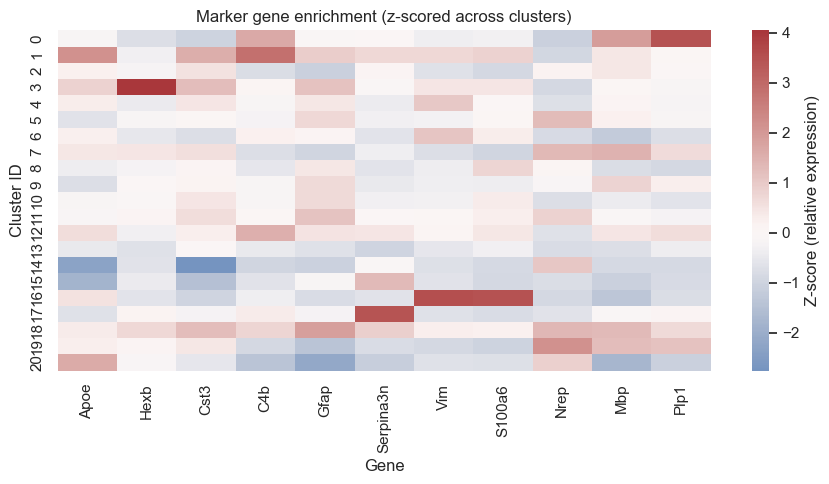

Apoe          1
Hexb          3
Cst3          1
C4b           1
Gfap         18
Serpina3n    17
Vim          16
S100a6       16
Nrep         19
Mbp           0
Plp1          0
Name: max_in_cluster, dtype: category
Categories (21, object): ['0', '1', '2', '3', ..., '17', '18', '19', '20']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Reuse previous marker set
marker_genes = {
    "microglia": ["Apoe", "Hexb", "Cst3", "C4b"],
    "astrocyte": ["Gfap", "Serpina3n", "Vim", "S100a6"],
    "neuron": ["Nrep", "Snap25", "Rbfox3"],
    "oligodendrocyte": ["Mbp", "Plp1", "Cldn11"],
}

genes_to_check = [
    g for v in marker_genes.values() for g in v if g in combined_df_normalized.columns
]
expr = combined_df_normalized.groupby("cluster_leiden")[genes_to_check].mean()

# z-score per gene (across clusters)
expr_z = (expr - expr.mean(axis=0)) / expr.std(axis=0)

plt.figure(figsize=(9, 5))
sns.heatmap(expr_z, cmap="vlag", center=0, cbar_kws={"label": "Z-score (relative expression)"})
plt.title("Marker gene enrichment (z-scored across clusters)")
plt.xlabel("Gene")
plt.ylabel("Cluster ID")
plt.tight_layout()
plt.show()

# Identify cluster with highest z for each marker
top_z = expr_z.idxmax(axis=0).rename("max_in_cluster")
display(top_z)

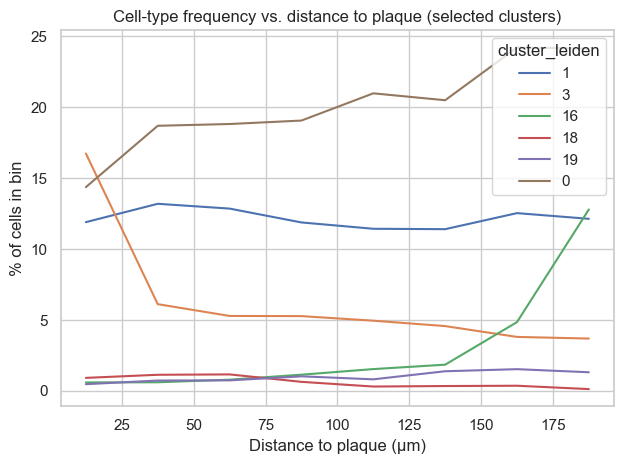

In [ ]:
sns.lineplot(
    data=freq_df,
    x="bin_mid",
    y="pct",
    hue="cluster_leiden",
    hue_order=["1", "3", "16", "18", "19", "0"],
)
plt.title("Cell-type frequency vs. distance to plaque (selected clusters)")
plt.xlabel("Distance to plaque (µm)")
plt.ylabel("% of cells in bin")
plt.tight_layout()
plt.show()

Research Question 3 — Relationship Between Gene Expression and Cell Type Composition

Step 1 – Quantify PIG expression and cell-type composition along distance

In [18]:
combined_df_normalized.head()

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,total_counts,cell_area,nucleus_area,...,Vwc2l,Wfs1,Zfp366,Zfp536,Zfpm2,distance_to_plaque,nearest_plaque_center_dist,inside_any_plaque,nearest_plaque_id,nearest_plaque_area
0,aaabiggh-1,831.785336,755.803772,554,0,0,0,554,509.091563,65.386250,...,1.386294,0.000000,0.0,0.0,0.693147,35.775568,37.777984,False,18,12.198375
1,aaacfoel-1,821.733453,768.910446,291,0,0,0,291,275.498281,36.982969,...,1.098612,0.000000,0.0,0.0,0.693147,37.307845,39.655874,False,19,16.476565
2,aaaeefil-1,831.932053,780.367651,220,1,0,0,221,261.635312,15.849844,...,0.000000,0.693147,0.0,0.0,1.098612,23.175138,25.481295,False,19,16.476565
3,aaaehidd-1,853.614108,774.764157,1029,0,0,0,1029,818.547344,129.056563,...,1.609438,1.609438,0.0,0.0,1.098612,7.118367,9.038409,False,18,12.198375
4,aaagcbkg-1,821.639603,799.171515,453,0,0,1,454,522.232031,96.002188,...,0.000000,0.000000,0.0,0.0,1.098612,26.299783,36.428680,False,21,204.299936


In [19]:
def clean_cell_id(x):
    # bytes -> str
    if isinstance(x, (bytes, bytearray, np.bytes_)):
        return x.decode("utf-8", errors="ignore")
    s = str(x)
    # in case the type is "b'xxxx'"
    if s.startswith("b'") and s.endswith("'"):
        return s[2:-1]
    return s

annot = pd.read_csv("src/data/xenium_annotations/Alzeimer_xenium_predicted_cell_types_with_ids.csv")

# rename cell_id column if needed
id_col = next((c for c in annot.columns if "cell" in c.lower() and "id" in c.lower()), None)
assert id_col is not None, f"Aucune colonne 'cell_id' repérée dans annot: {annot.columns.tolist()}"

annot = annot.rename(columns={id_col: "cell_id"})

# normalize cell_id format
annot["cell_id"] = annot["cell_id"].apply(clean_cell_id)

# useful columns only
keep_cols = ["cell_id", "cell_type", "coord_X", "coord_Y", "predicted_label"]
keep_cols = [c for c in keep_cols if c in annot.columns]
annot = annot[keep_cols]

annot.head()

,cell_id,cell_type,coord_X,coord_Y,predicted_label
0,aaabfoap-1,30 Astro-Epen,843.68823,608.29816,29
1,aaabonpk-1,30 Astro-Epen,851.08930,612.55554,29
2,aaadnjke-1,22 MB-HB Sero,833.55740,611.50134,21
3,aaaeilha-1,30 Astro-Epen,840.11130,616.14453,29
4,aaaenhoh-1,33 Vascular,824.70930,622.89410,32


In [20]:
before = combined_df_normalized.shape[0]
cells = combined_df_normalized.merge(annot, on="cell_id", how="left")
print(f"Merged: {before} -> {cells.shape[0]} rows")

# diagnostic : cells with no annotation
match_rate = cells["cell_type"].notna().mean() if "cell_type" in cells.columns else 0.0
print(f"Annotated cells rate: {match_rate:.1%}")

# if predicted_label is present, check for unknown labels (34)
if "predicted_label" in cells.columns:
    unknown = (cells["predicted_label"] == 34).sum()
    if unknown:
        print(f"Attention: {unknown} cells with predicted_label==34 (not a valid tag).")

if "distance_bin" not in cells.columns:
    cells["distance_bin"] = pd.cut(
        cells["distance_to_plaque"],
        bins=[0, 20, 50, 100, 200, 1e9],
        labels=["0-20", "20-50", "50-100", "100-200", ">200"],
        include_lowest=True
    )

Merged: 53895 -> 53895 rows
Annotated cells rate: 80.9%
Attention: 6332 cells with predicted_label==34 (not a valid tag).


Bin proportion

In [21]:
PIGS = ["Hexb","Cst3","CD63","C4b","Ctsd","B2m","H2-K1","Apoe",
        "Gfap","Nrep","Serpina3n","Cd74","Cxcl10","Vim","S100a6","Ifit3"]

# per bin proportions of cell types
props = (
    cells.groupby(["distance_bin","cell_type"])
         .size().rename("n").reset_index()
)
props["proportion"] = props.groupby("distance_bin")["n"].transform(lambda x: x/x.sum())

In [22]:
# sanity check

# Order distance_bin categories
cells["distance_bin"] = cells["distance_bin"].astype("category")
cells["distance_bin"] = cells["distance_bin"].cat.reorder_categories(
    ["0-20","20-50","50-100","100-200",">200"], ordered=True
)

# Sum of proportions per bin (should be ~1.0)
test = props.groupby("distance_bin")["proportion"].sum().round(6)
print("Somme des proportions par bin:", dict(test))

Somme des proportions par bin: {'0-20': 1.0, '20-50': 1.0, '50-100': 1.0, '100-200': 1.0, '>200': 1.0}


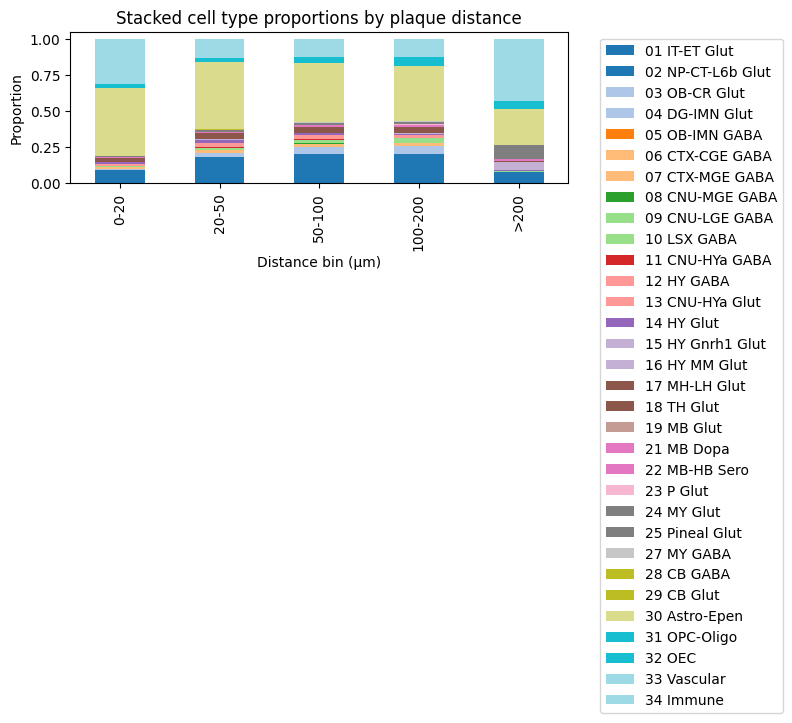

In [23]:
cell_type_prop_by_dist(props)

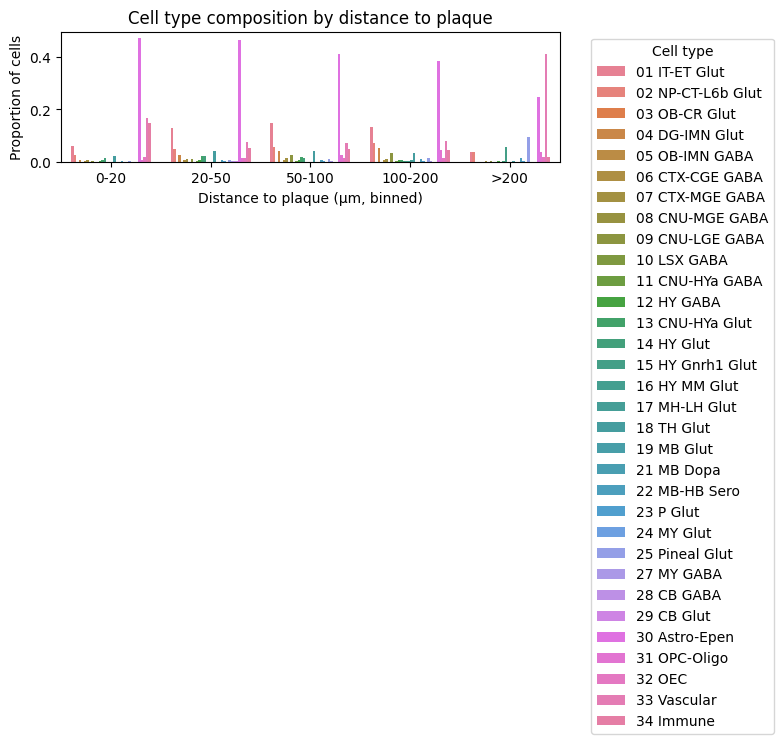

In [24]:
cell_type_comp_by_dist(props)

Mean PIG per bin

In [25]:
pig_cols = [g for g in PIGS if g in cells.columns]
mean_by_bin = cells.groupby("distance_bin")[pig_cols].mean().reset_index()

# Sanity check
# PIGS are numeric
pig_cols = [g for g in PIGS if g in cells.columns and pd.api.types.is_numeric_dtype(cells[g])]
assert len(pig_cols) > 0, "Aucun PIG numérique trouvé (vérifie les noms/casse)."

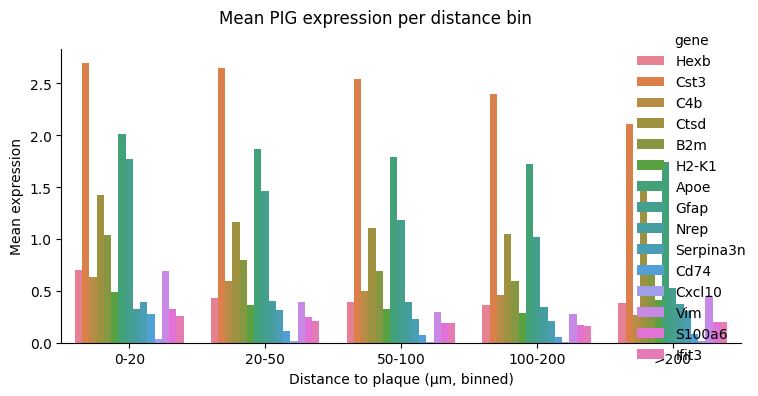

In [26]:
mean_melt = mean_by_bin.melt(id_vars="distance_bin", value_vars=pig_cols,
                             var_name="gene", value_name="mean_expr")

mean_exp_dist(mean_melt)

Cellular composition vs distance

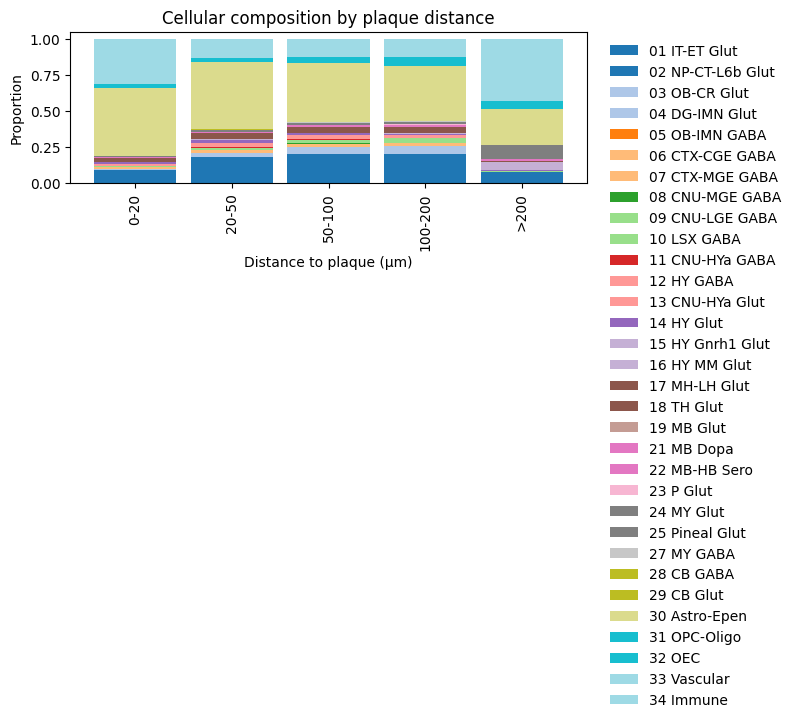

In [27]:
import matplotlib.pyplot as plt
pivot_prop = props.pivot_table(index="distance_bin", columns="cell_type",
                               values="proportion", aggfunc="mean").fillna(0)
cellular_comp_by_dist(pivot_prop)

PIG curve vs distance

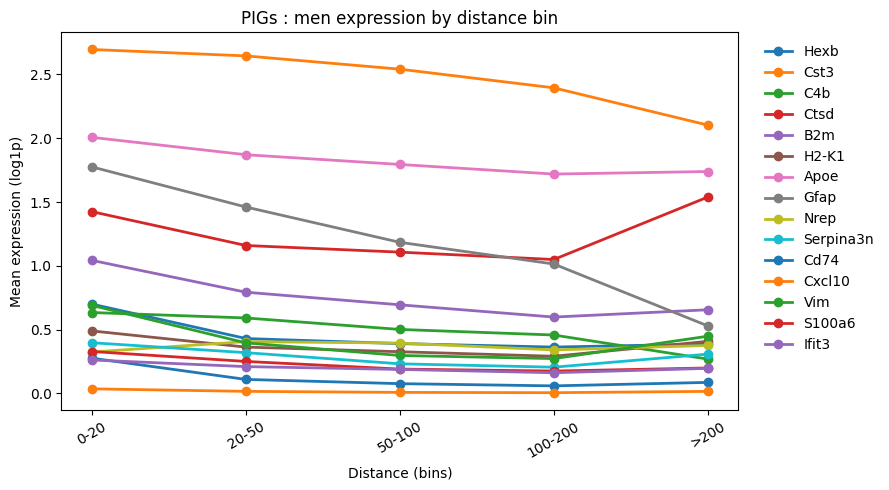

In [28]:
mean_by_bin = cells.groupby("distance_bin")[pig_cols].mean().reset_index()
pig_expr_by_dist(mean_by_bin, pig_cols)

Heatmap correlation PIG vs composition

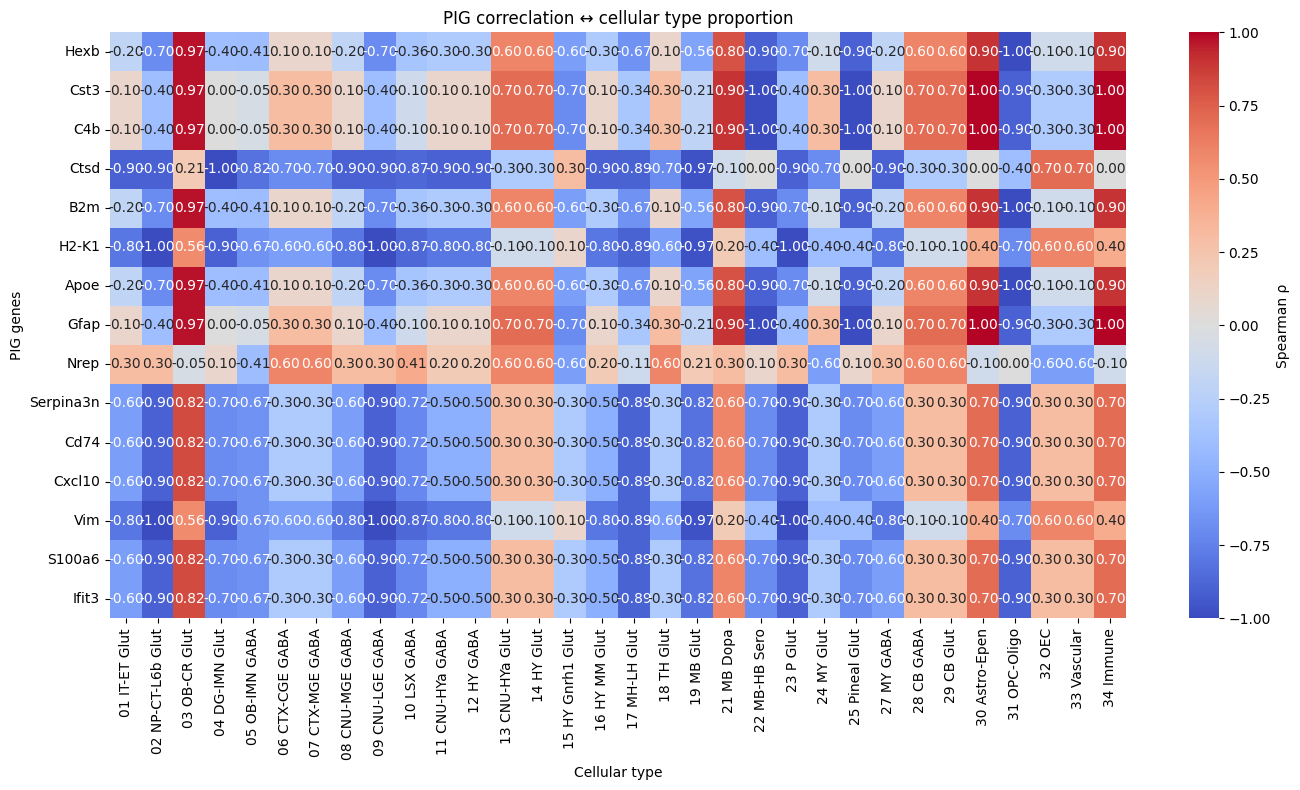

In [29]:
# Align matrices on same bins
pig_mat  = mean_by_bin.set_index("distance_bin")[pig_cols]
prop_mat = pivot_prop.loc[pig_mat.index]  # align index
pig_comp_heatmap(pig_mat, prop_mat, pig_cols)


Regression analysis : do composition explain PIG (above distance) ?

In [30]:


def simplify_celltype(ct):
    if pd.isna(ct):
        return "Unlabeled"
    ct = str(ct)
    if "Glut" in ct:
        return "Glutamatergic"
    if "GABA" in ct:
        return "GABAergic"
    if any(x in ct for x in ["Astro", "Micro", "Oligo"]):
        return "Glial"
    return "Other"

# si tu as predicted_label==34 pour "inconnu", on l’étiquette aussi
if "predicted_label" in cells.columns:
    cells.loc[cells["predicted_label"] == 34, "cell_type"] = pd.NA

cells["broad_type"] = cells["cell_type"].apply(simplify_celltype)

df = cells[["Apoe", "distance_to_plaque", "broad_type"]].dropna()
res = smf.ols("Apoe ~ distance_to_plaque + C(broad_type)", data=df).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                   Apoe   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     2901.
Date:                Wed, 29 Oct 2025   Prob (F-statistic):               0.00
Time:                        00:11:10   Log-Likelihood:                -59281.
No. Observations:               53895   AIC:                         1.186e+05
Df Residuals:                   53889   BIC:                         1.186e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

All genes regression

In [31]:
results = []
for gene in PIGS:
    if gene not in cells.columns:
        continue
    df = cells[["distance_to_plaque", gene, "broad_type"]].dropna()
    res = smf.ols(f"Q('{gene}') ~ distance_to_plaque + C(broad_type)", data=df).fit()
    for var in res.params.index:
        results.append({
            "gene": gene,
            "variable": var,
            "coef": res.params[var],
            "pval": res.pvalues[var]
        })
results_df = pd.DataFrame(results)
results_df.head()

,gene,variable,coef,pval
0,Hexb,Intercept,0.453781,3.511984e-289
1,Hexb,C(broad_type)[T.Glial],0.040108,1.226754e-03
2,Hexb,C(broad_type)[T.Glutamatergic],0.042699,7.851262e-04
3,Hexb,C(broad_type)[T.Other],0.404848,4.627914e-197
4,Hexb,C(broad_type)[T.Unlabeled],-0.028656,2.796668e-02


In [32]:

PIGS = ["Hexb","Cst3","CD63","C4b","Ctsd","B2m","H2-K1","Apoe",
        "Gfap","Nrep","Serpina3n","Cd74","Cxcl10","Vim","S100a6","Ifit3"]
PIGS = [g for g in PIGS if g in cells.columns]

def _simplify(ct: str) -> str:
    if pd.isna(ct): return "Unlabeled"
    ct = str(ct)
    if "Glut" in ct: return "Glutamatergic"
    if "GABA" in ct: return "GABAergic"
    if any(x in ct for x in ["Astro","Micro","Oligo"]): return "Glial"
    return "Other"

if "broad_type" not in cells.columns:
    cells = cells.copy()
    cells["broad_type"] = cells["cell_type"].apply(_simplify)

bin_order = ["0-20","20-50","50-100","100-200",">200"]

# --- mean and SEM per (gene, broad_type, bin)
long = (
    cells.melt(
        id_vars=["distance_bin","broad_type"],
        value_vars=PIGS,
        var_name="gene",
        value_name="expression"
    )
    .dropna(subset=["expression"])
)

agg = (long
       .groupby(["gene","broad_type","distance_bin"], observed=True)
       .agg(mean=("expression","mean"),
            sem=("expression", lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0.0),
            n=("expression","size"))
       .reset_index())

agg["distance_bin"] = pd.Categorical(agg["distance_bin"], categories=bin_order, ordered=True)
agg = agg.sort_values(["gene","broad_type","distance_bin"])

interactive_comp_pig_regression(agg,PIGS, bin_order)


Saved to figures/pig_by_distance_interactive.html
Saved to figures/pig_by_distance_interactive.html


Research Question 4

In [139]:
meta_cols = [
    "cell_id", "x_centroid", "y_centroid", "transcript_counts", "control_probe_counts",
    "control_codeword_counts", "unassigned_codeword_counts", "total_counts", "cell_area",
    "nucleus_area", "inside_any_plaque", "nearest_plaque_id", "nearest_plaque_center_dist",
    "closest_point_x", "closest_point_y", "nearest_plaque_area", "dist_bin_proximal_distal", "n_genes"
]

exclude_cols = [
    "distance_to_plaque", "nearest_plaque_center_dist", "nearest_plaque_area", "nearest_plaque_dist",
    "closest_point_x", "closest_point_y"
]

gene_cols = [
    c for c in cells_with_distances.columns
    if c not in meta_cols + exclude_cols
]

print(f"Cleaned gene columns: {len(gene_cols)}")
print("First few genes:", gene_cols[:10])


Cleaned gene columns: 347
First few genes: ['2010300C02Rik', 'Abca7', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adgrl4', 'Aldh1a2', 'Aldh1l1']


In [140]:
X = cells_with_distances[gene_cols].copy()
y = cells_with_distances["nearest_plaque_center_dist"].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("Target NaN count:", np.isnan(y).sum())


X shape: (53895, 347)
y shape: (53895,)
Target NaN count: 0


In [141]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train_scaled.shape}, Test shape: {X_test_scaled.shape}")
print(f"Mean of first 5 genes (train, after scaling): {X_train_scaled[:, :5].mean(axis=0)}")
print(f"Std  of first 5 genes (train, after scaling): {X_train_scaled[:, :5].std(axis=0)}")

Train shape: (43116, 347), Test shape: (10779, 347)
Mean of first 5 genes (train, after scaling): [-6.37767972e-17  5.86680615e-17  4.03754918e-17 -1.91165594e-17
  4.68644101e-17]
Std  of first 5 genes (train, after scaling): [1. 1. 1. 1. 1.]


In [ ]:
models = {
    "lasso": pm.run_lasso,
    "elasticnet": pm.run_elasticnet,
    "rf": pm.run_rf,
    "xgb": pm.run_xgb,
}

trained_models = {}   
results_list = []
importance_frames = []

for name, fn in models.items():
    print(f"Running {name.upper()} ")
    model, results, imp = fn(X_train_scaled, X_test_scaled, y_train, y_test, gene_cols)
    
    trained_models[name] = model     
    results_list.append(results)
    imp["model"] = name
    importance_frames.append(imp)

results_df = pd.DataFrame(results_list)
importance_df = pd.concat(importance_frames, ignore_index=True)

print("\nModel performance summary:")
display(results_df)

Running LASSO 
Running ELASTICNET 
Running RF 
Running XGB 

Model performance summary:


,model,train_r2,test_r2,alpha,l1_ratio
0,LASSO,0.201852,0.192679,0.075282,NaN
1,ElasticNet,0.201852,0.192631,0.078009,0.9
2,RandomForest,0.230002,0.179160,NaN,NaN
3,XGBoost,0.498746,0.254471,NaN,NaN


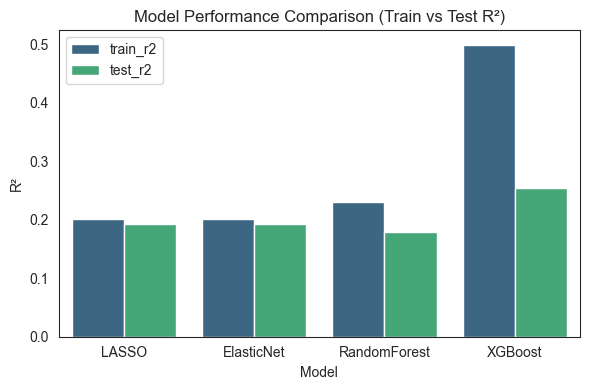

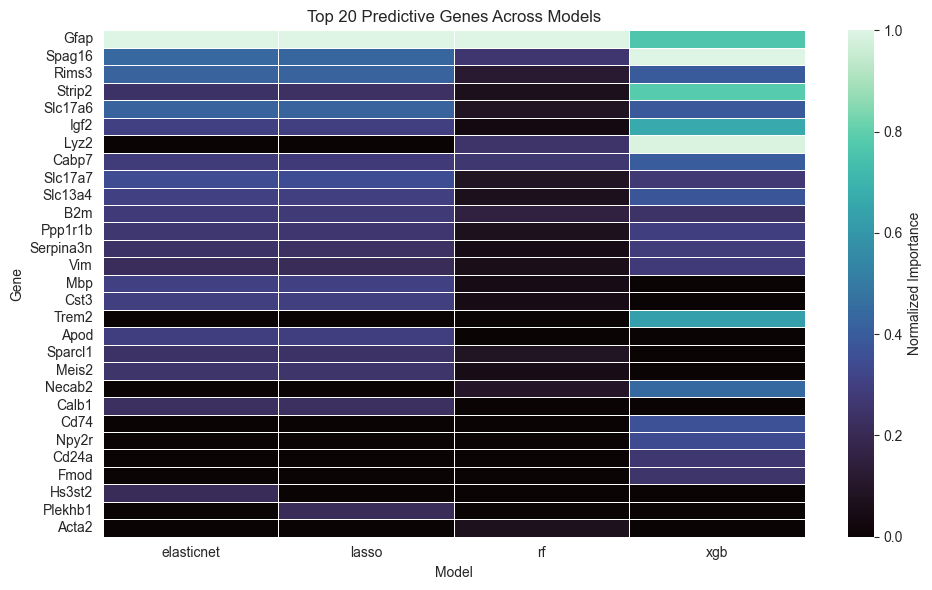

Top genes for XGB: ['Spag16', 'Lyz2', 'Strip2', 'Gfap', 'Igf2']


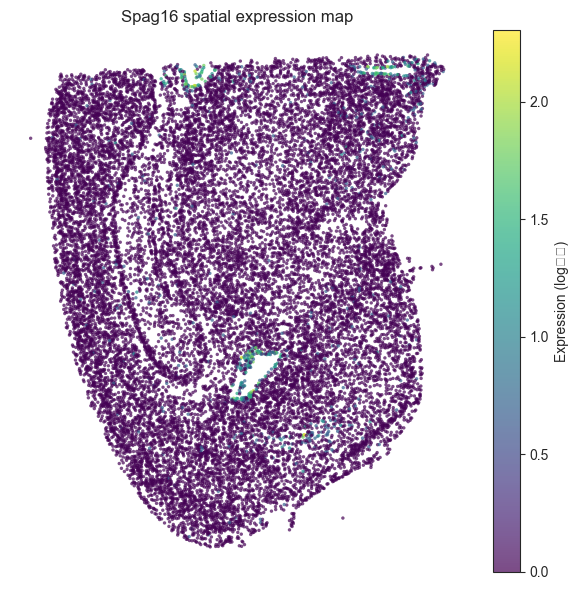

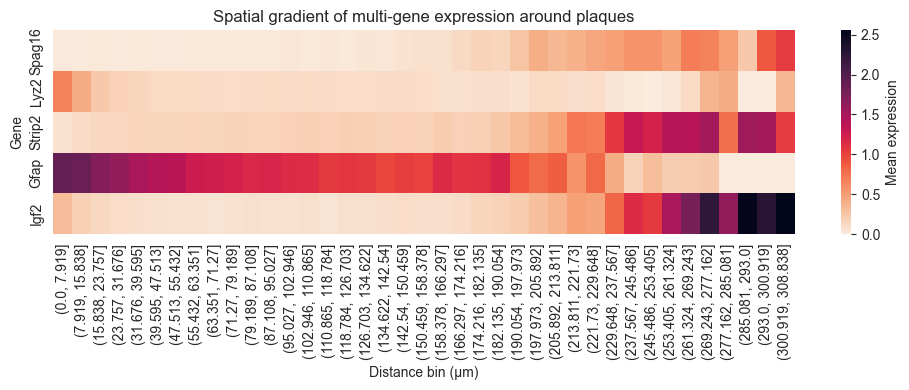

In [ ]:
plot_model_performance(results_df)

plot_top_gene_importances(importance_df, top_n=20)

best_model = 'xgb'
top_genes = (
    importance_df[importance_df["model"].str.lower() == best_model.lower()]
    .nlargest(5, "importance")["gene"]
    .tolist()
)

print(f"Top genes for {best_model.upper()}: {top_genes}")

plot_spatial_overlay(cells_with_distances, gene=top_genes[0])
plot_multi_gene_signature(cells_with_distances, top_genes)


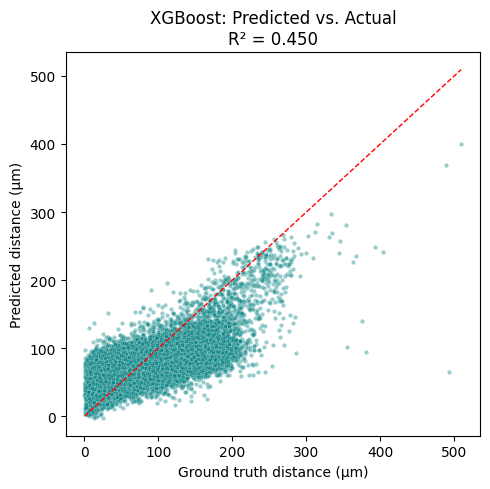

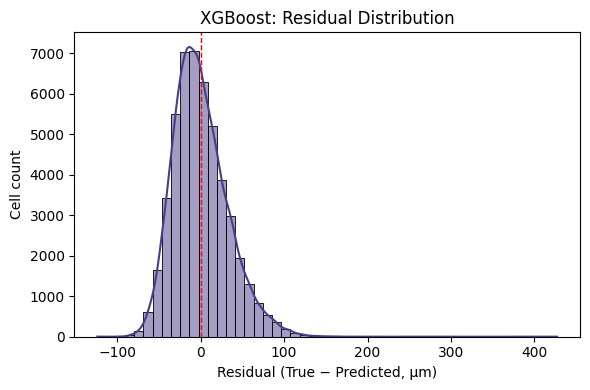

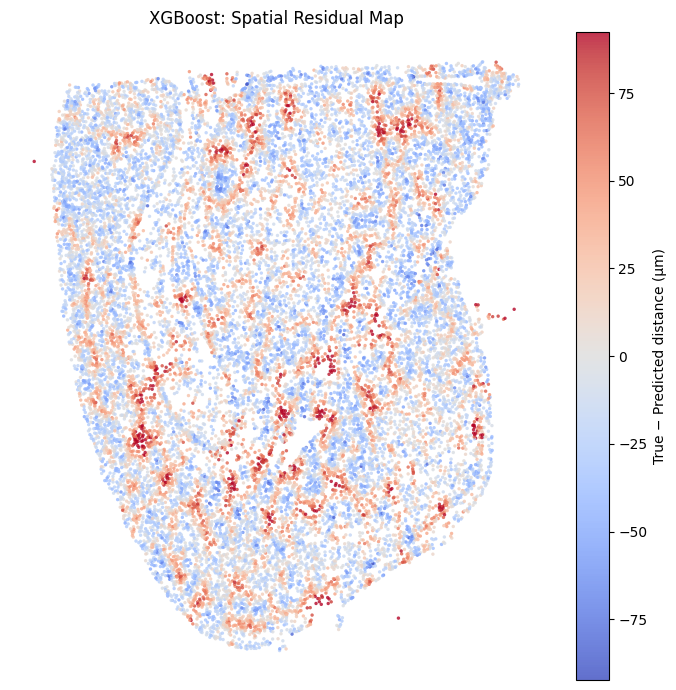

In [ ]:
xgb_reg = trained_models["xgb"]
y_true = cells_with_distances["nearest_plaque_center_dist"]
X_scaled_all = scaler.transform(cells_with_distances[gene_cols])
y_pred = xgb_reg.predict(X_scaled_all)

plot_pred_vs_true(y_true, y_pred, model_name="XGBoost")

plot_residual_hist(y_true, y_pred, model_name="XGBoost")

plot_spatial_residual_map(cells_with_distances, y_true, y_pred, model_name="XGBoost")


In [ ]:
residual = y_true - y_pred
cells_with_distances["residual"] = y_true - y_pred
abs_resid = cells_with_distances["residual"].abs()

# Quantile cutoffs (top 10% worst predicted)
threshold = abs_resid.quantile(0.90)
poor_cells = cells_with_distances[abs_resid >= threshold]
well_cells = cells_with_distances[abs_resid < threshold]


In [ ]:
import pandas as pd
import numpy as np

corrs = []
for g in gene_cols:
    if cells_with_distances[g].var() > 0:
        r = np.corrcoef(cells_with_distances[g], cells_with_distances["residual"])[0, 1]
        corrs.append((g, r))

corr_df = pd.DataFrame(corrs, columns=["gene", "pearson_r"]).dropna()
corr_df["abs_r"] = corr_df["pearson_r"].abs()
corr_df.sort_values("abs_r", ascending=False).head(15)


,gene,pearson_r,abs_r
156,Igf1,-0.009934,0.009934
35,Calb1,-0.009619,0.009619
15,Arc,0.008171,0.008171
225,Osmr,-0.008111,0.008111
325,Tmem119,0.008098,0.008098
290,Slc17a7,0.008039,0.008039
280,Sema3e,0.007921,0.007921
214,Ntng1,-0.007754,0.007754
55,Cdh4,-0.007667,0.007667
285,Siglech,0.007637,0.007637


In [ ]:
corrs = []
for g in gene_cols:
    rho, _ = spearmanr(cells_with_distances[g], cells_with_distances["residual"])
    corrs.append((g, rho))

In [ ]:
abs_resid = cells_with_distances["residual"].abs()
thr = abs_resid.quantile(0.90)

poor = cells_with_distances.loc[abs_resid >= thr, gene_cols].mean()
good = cells_with_distances.loc[abs_resid < thr, gene_cols].mean()

delta = (poor - good).sort_values(ascending=False)
delta.head(15)


Plp1       0.138953
Apod       0.110482
Mobp       0.110391
Cnp        0.099800
Gjc3       0.063149
Mbp        0.051696
Gatm       0.050914
Opalin     0.049425
Sox10      0.033524
Plekhb1    0.031863
Zfp536     0.021737
Itgb4      0.021131
Olig2      0.016250
Gsn        0.011685
Tppp3      0.007822
dtype: float64

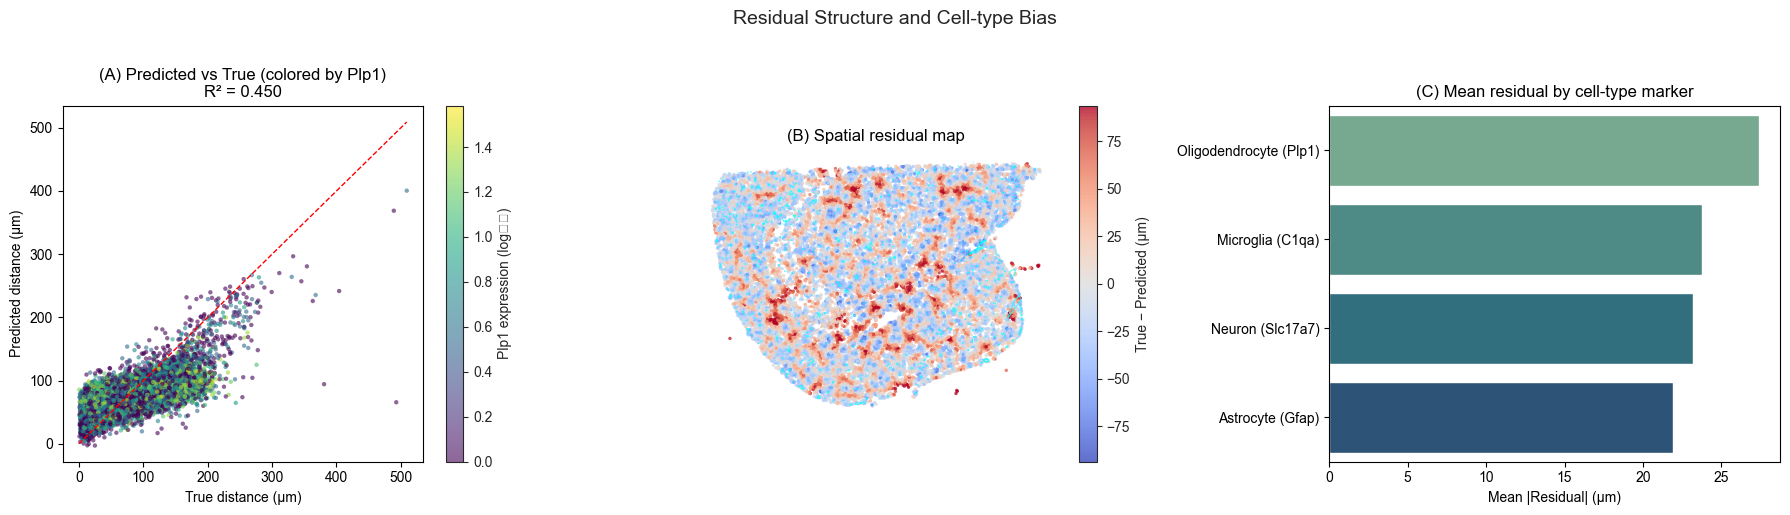

{'r2': 0.44958853734370885,
 'mean_resids': Oligodendrocyte (Plp1)    27.365989
 Microglia (C1qa)          23.754151
 Neuron (Slc17a7)          23.184229
 Astrocyte (Gfap)          21.928205
 dtype: float64}

In [ ]:
plot.plot_residual_figure(cells_with_distances, y_true, y_pred, gene_cols, plaques_poly)